# 🏠 House Price Estimator
### End-to-End Machine Learning Pipeline on Real Dataset

---

| # | Step |
|---|------|
| 1 | Define the Problem |
| 2 | Collect and Prepare Data |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Split the Data |
| 6 | Choose a Model |
| 7 | Train the Model |
| 8 | Evaluate the Model |
| 9 | Improve the Model |
| 10 | Deploy the Model |

**Dataset:** `House Price Prediction Dataset.csv` — 2000 samples, 9 features, target: `Price`


---
## ⚙️ Global Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor'  : '#0d0d1a',
    'axes.facecolor'    : '#13132b',
    'axes.edgecolor'    : '#3a3a5c',
    'axes.labelcolor'   : '#dde0ff',
    'xtick.color'       : '#b0b3d6',
    'ytick.color'       : '#b0b3d6',
    'text.color'        : '#dde0ff',
    'grid.color'        : '#25254a',
    'grid.alpha'        : 0.55,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 12,
    'axes.labelsize'    : 11,
    'font.family'       : 'DejaVu Sans',
    'figure.dpi'        : 120,
})

PALETTE  = ['#7c4dff','#ff6b9d','#00e5cc','#ffca28','#42a5f5','#ef5350','#66bb6a','#ab47bc']
CMAP_DIV = 'coolwarm'

print('Libraries loaded. Dark theme active.')

Libraries loaded. Dark theme active.


---
## Step 1 — Define the Problem


In [2]:
info = {
    'Problem Type'      : 'Supervised Regression',
    'Objective'         : 'Predict the sale price of a house given its features',
    'Target Variable'   : 'Price  (continuous, in USD)',
    'Input Features'    : 'Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage',
    'Dataset Size'      : '2,000 samples  |  10 columns  |  0 missing values',
    'Evaluation Metrics': 'R² Score, RMSE, MAE',
    'Algorithms'        : 'Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost',
}
print('=' * 62)
print('         HOUSE PRICE ESTIMATOR — PROBLEM DEFINITION')
print('=' * 62)
for k, v in info.items():
    print(f'  {k:<22}: {v}')
print('=' * 62)

         HOUSE PRICE ESTIMATOR — PROBLEM DEFINITION
  Problem Type          : Supervised Regression
  Objective             : Predict the sale price of a house given its features
  Target Variable       : Price  (continuous, in USD)
  Input Features        : Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage
  Dataset Size          : 2,000 samples  |  10 columns  |  0 missing values
  Evaluation Metrics    : R² Score, RMSE, MAE
  Algorithms            : Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost


---
## Step 2 — Collect and Prepare Data


In [3]:
df = pd.read_csv('House Price Prediction Dataset.csv')

print('Dataset loaded successfully!')
print(f'Shape       : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('\n--- First 5 Rows ---')
df.head()

Dataset loaded successfully!
Shape       : 2000 rows × 10 columns
Memory usage: 471.5 KB

--- First 5 Rows ---


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
print('--- Column Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')

--- Column Data Types ---
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

--- Missing Values ---
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Total missing cells: 0


In [5]:
print('--- Unique Values per Categorical Column ---')
for col in ['Location', 'Condition', 'Garage']:
    print(f'  {col}: {df[col].unique().tolist()}  (n={df[col].nunique()})')

print('\n--- Statistical Summary ---')
df.describe().T

--- Unique Values per Categorical Column ---
  Location: ['Downtown', 'Suburban', 'Urban', 'Rural']  (n=4)
  Condition: ['Excellent', 'Good', 'Fair', 'Poor']  (n=4)
  Garage: ['No', 'Yes']  (n=2)

--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


In [6]:
df.drop(columns=['Id'], inplace=True)

print('Data Preparation Complete.')
print(f'  Rows     : {len(df)}')
print(f'  Columns  : {df.columns.tolist()}')
print(f'  Missing  : {df.isnull().sum().sum()}')
print(f'  Duplicates: {df.duplicated().sum()}')

Data Preparation Complete.
  Rows     : 2000
  Columns  : ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']
  Missing  : 0


  Duplicates: 0


---
## Step 3 — Exploratory Data Analysis (EDA)


Skewness  Raw : -0.0644
Skewness  Log : -1.0786


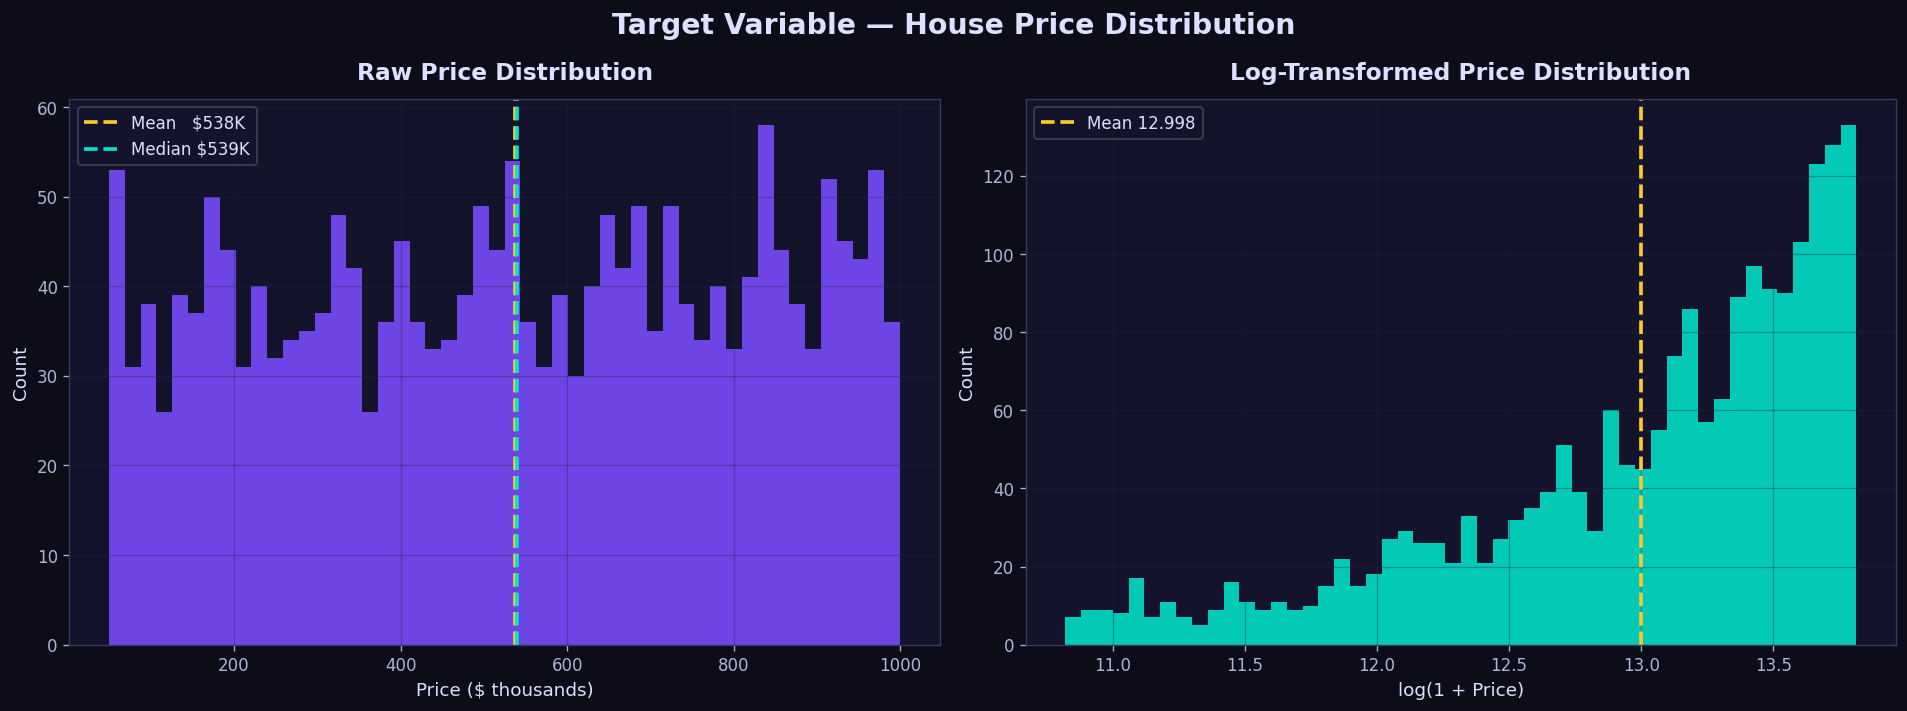

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Target Variable — House Price Distribution', fontsize=17, fontweight='bold', color='#dde0ff')

axes[0].hist(df['Price'] / 1000, bins=50, color='#7c4dff', edgecolor='none', alpha=0.88)
axes[0].axvline(df['Price'].mean()   / 1000, color='#ffca28', lw=2.2, ls='--',
                label=f'Mean   ${df["Price"].mean()/1000:.0f}K')
axes[0].axvline(df['Price'].median() / 1000, color='#00e5cc', lw=2.2, ls='--',
                label=f'Median ${df["Price"].median()/1000:.0f}K')
axes[0].set_title('Raw Price Distribution')
axes[0].set_xlabel('Price ($ thousands)')
axes[0].set_ylabel('Count')
axes[0].legend(framealpha=0.25)
axes[0].grid(True, alpha=0.35)

log_price = np.log1p(df['Price'])
axes[1].hist(log_price, bins=50, color='#00e5cc', edgecolor='none', alpha=0.88)
axes[1].axvline(log_price.mean(), color='#ffca28', lw=2.2, ls='--',
                label=f'Mean {log_price.mean():.3f}')
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')
axes[1].legend(framealpha=0.25)
axes[1].grid(True, alpha=0.35)

skew_raw = df['Price'].skew()
skew_log = log_price.skew()
print(f'Skewness  Raw : {skew_raw:.4f}')
print(f'Skewness  Log : {skew_log:.4f}')

plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

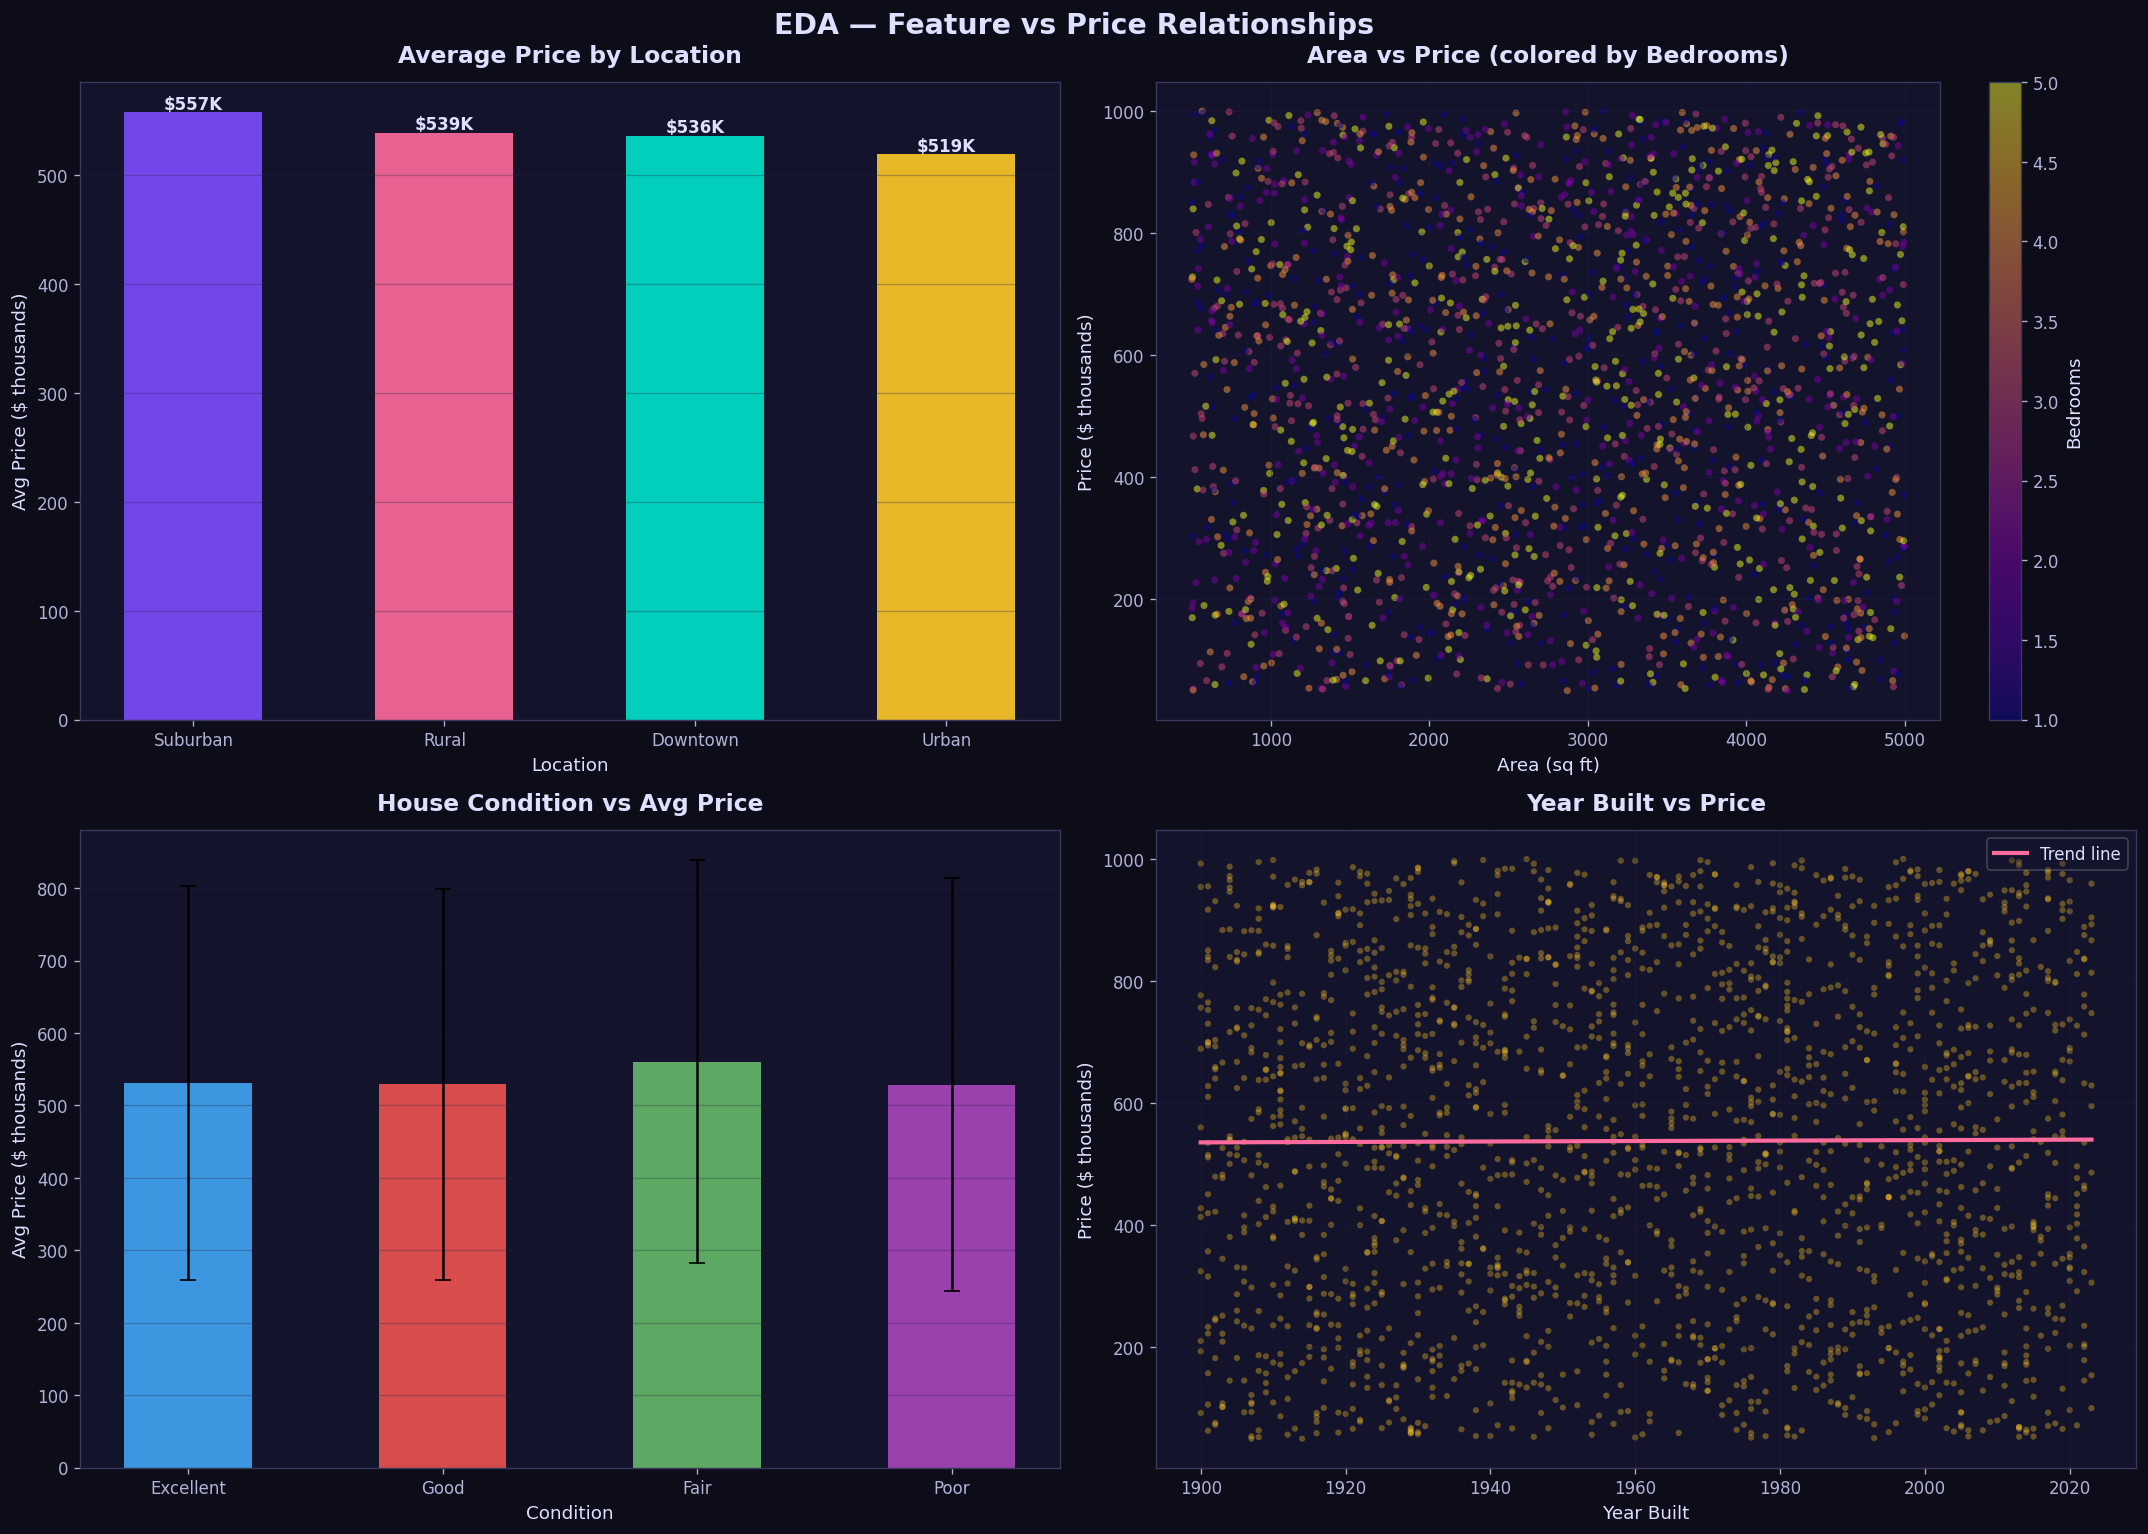

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('EDA — Feature vs Price Relationships', fontsize=17, fontweight='bold', color='#dde0ff')

loc_means = df.groupby('Location')['Price'].mean().sort_values(ascending=False) / 1000
bars = axes[0, 0].bar(loc_means.index, loc_means.values, color=PALETTE[:4], edgecolor='none', alpha=0.9, width=0.55)
axes[0, 0].set_title('Average Price by Location')
axes[0, 0].set_xlabel('Location')
axes[0, 0].set_ylabel('Avg Price ($ thousands)')
axes[0, 0].grid(True, axis='y', alpha=0.3)
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                    f'${bar.get_height():.0f}K', ha='center', fontsize=10, color='#dde0ff', fontweight='bold')

sc = axes[0, 1].scatter(df['Area'], df['Price'] / 1000,
                         c=df['Bedrooms'], cmap='plasma', alpha=0.5, s=18, edgecolors='none')
plt.colorbar(sc, ax=axes[0, 1], label='Bedrooms')
axes[0, 1].set_title('Area vs Price (colored by Bedrooms)')
axes[0, 1].set_xlabel('Area (sq ft)')
axes[0, 1].set_ylabel('Price ($ thousands)')
axes[0, 1].grid(True, alpha=0.3)

cond_order = ['Excellent', 'Good', 'Fair', 'Poor']
cond_means = [df[df['Condition'] == c]['Price'].mean() / 1000 for c in cond_order]
cond_stds  = [df[df['Condition'] == c]['Price'].std()  / 1000 for c in cond_order]
axes[1, 0].bar(cond_order, cond_means, yerr=cond_stds, color=PALETTE[4:8], edgecolor='none',
               alpha=0.9, width=0.5, capsize=5, error_kw={'color': '#ff6b9d', 'lw': 1.5})
axes[1, 0].set_title('House Condition vs Avg Price')
axes[1, 0].set_xlabel('Condition')
axes[1, 0].set_ylabel('Avg Price ($ thousands)')
axes[1, 0].grid(True, axis='y', alpha=0.3)

axes[1, 1].scatter(df['YearBuilt'], df['Price'] / 1000,
                   c='#ffca28', alpha=0.35, s=14, edgecolors='none')
z = np.polyfit(df['YearBuilt'], df['Price'] / 1000, 1)
p = np.poly1d(z)
xl = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 300)
axes[1, 1].plot(xl, p(xl), color='#ff6b9d', lw=2.5, label='Trend line')
axes[1, 1].set_title('Year Built vs Price')
axes[1, 1].set_xlabel('Year Built')
axes[1, 1].set_ylabel('Price ($ thousands)')
axes[1, 1].legend(framealpha=0.25)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_eda_relationships.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

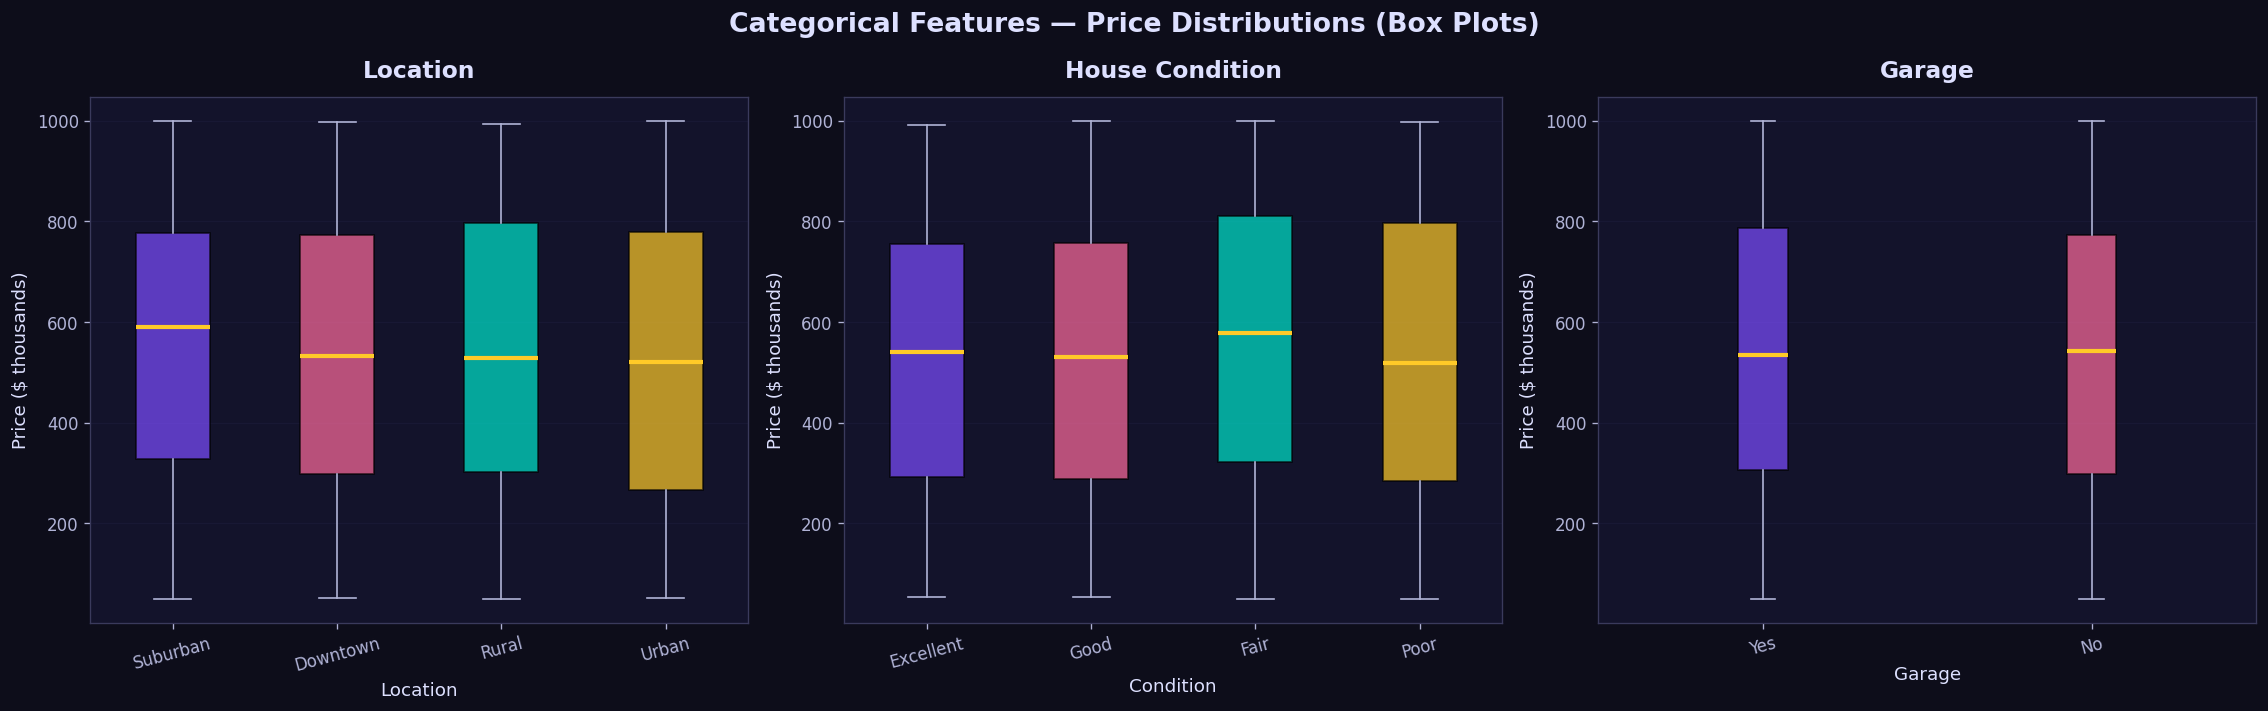

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Categorical Features — Price Distributions (Box Plots)', fontsize=16, fontweight='bold', color='#dde0ff')

loc_order  = df.groupby('Location')['Price'].median().sort_values(ascending=False).index.tolist()
cond_order = ['Excellent', 'Good', 'Fair', 'Poor']

for ax, col, order, title in zip(
        axes,
        ['Location', 'Condition', 'Garage'],
        [loc_order, cond_order, ['Yes', 'No']],
        ['Location', 'House Condition', 'Garage']):
    data_groups = [df[df[col] == g]['Price'].values / 1000 for g in order]
    bp = ax.boxplot(data_groups, labels=order, patch_artist=True,
                    medianprops={'color': '#ffca28', 'linewidth': 2.5},
                    whiskerprops={'color': '#b0b3d6'},
                    capprops={'color': '#b0b3d6'},
                    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4, 'color': '#ff6b9d'})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Price ($ thousands)')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('03_boxplots_categorical.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

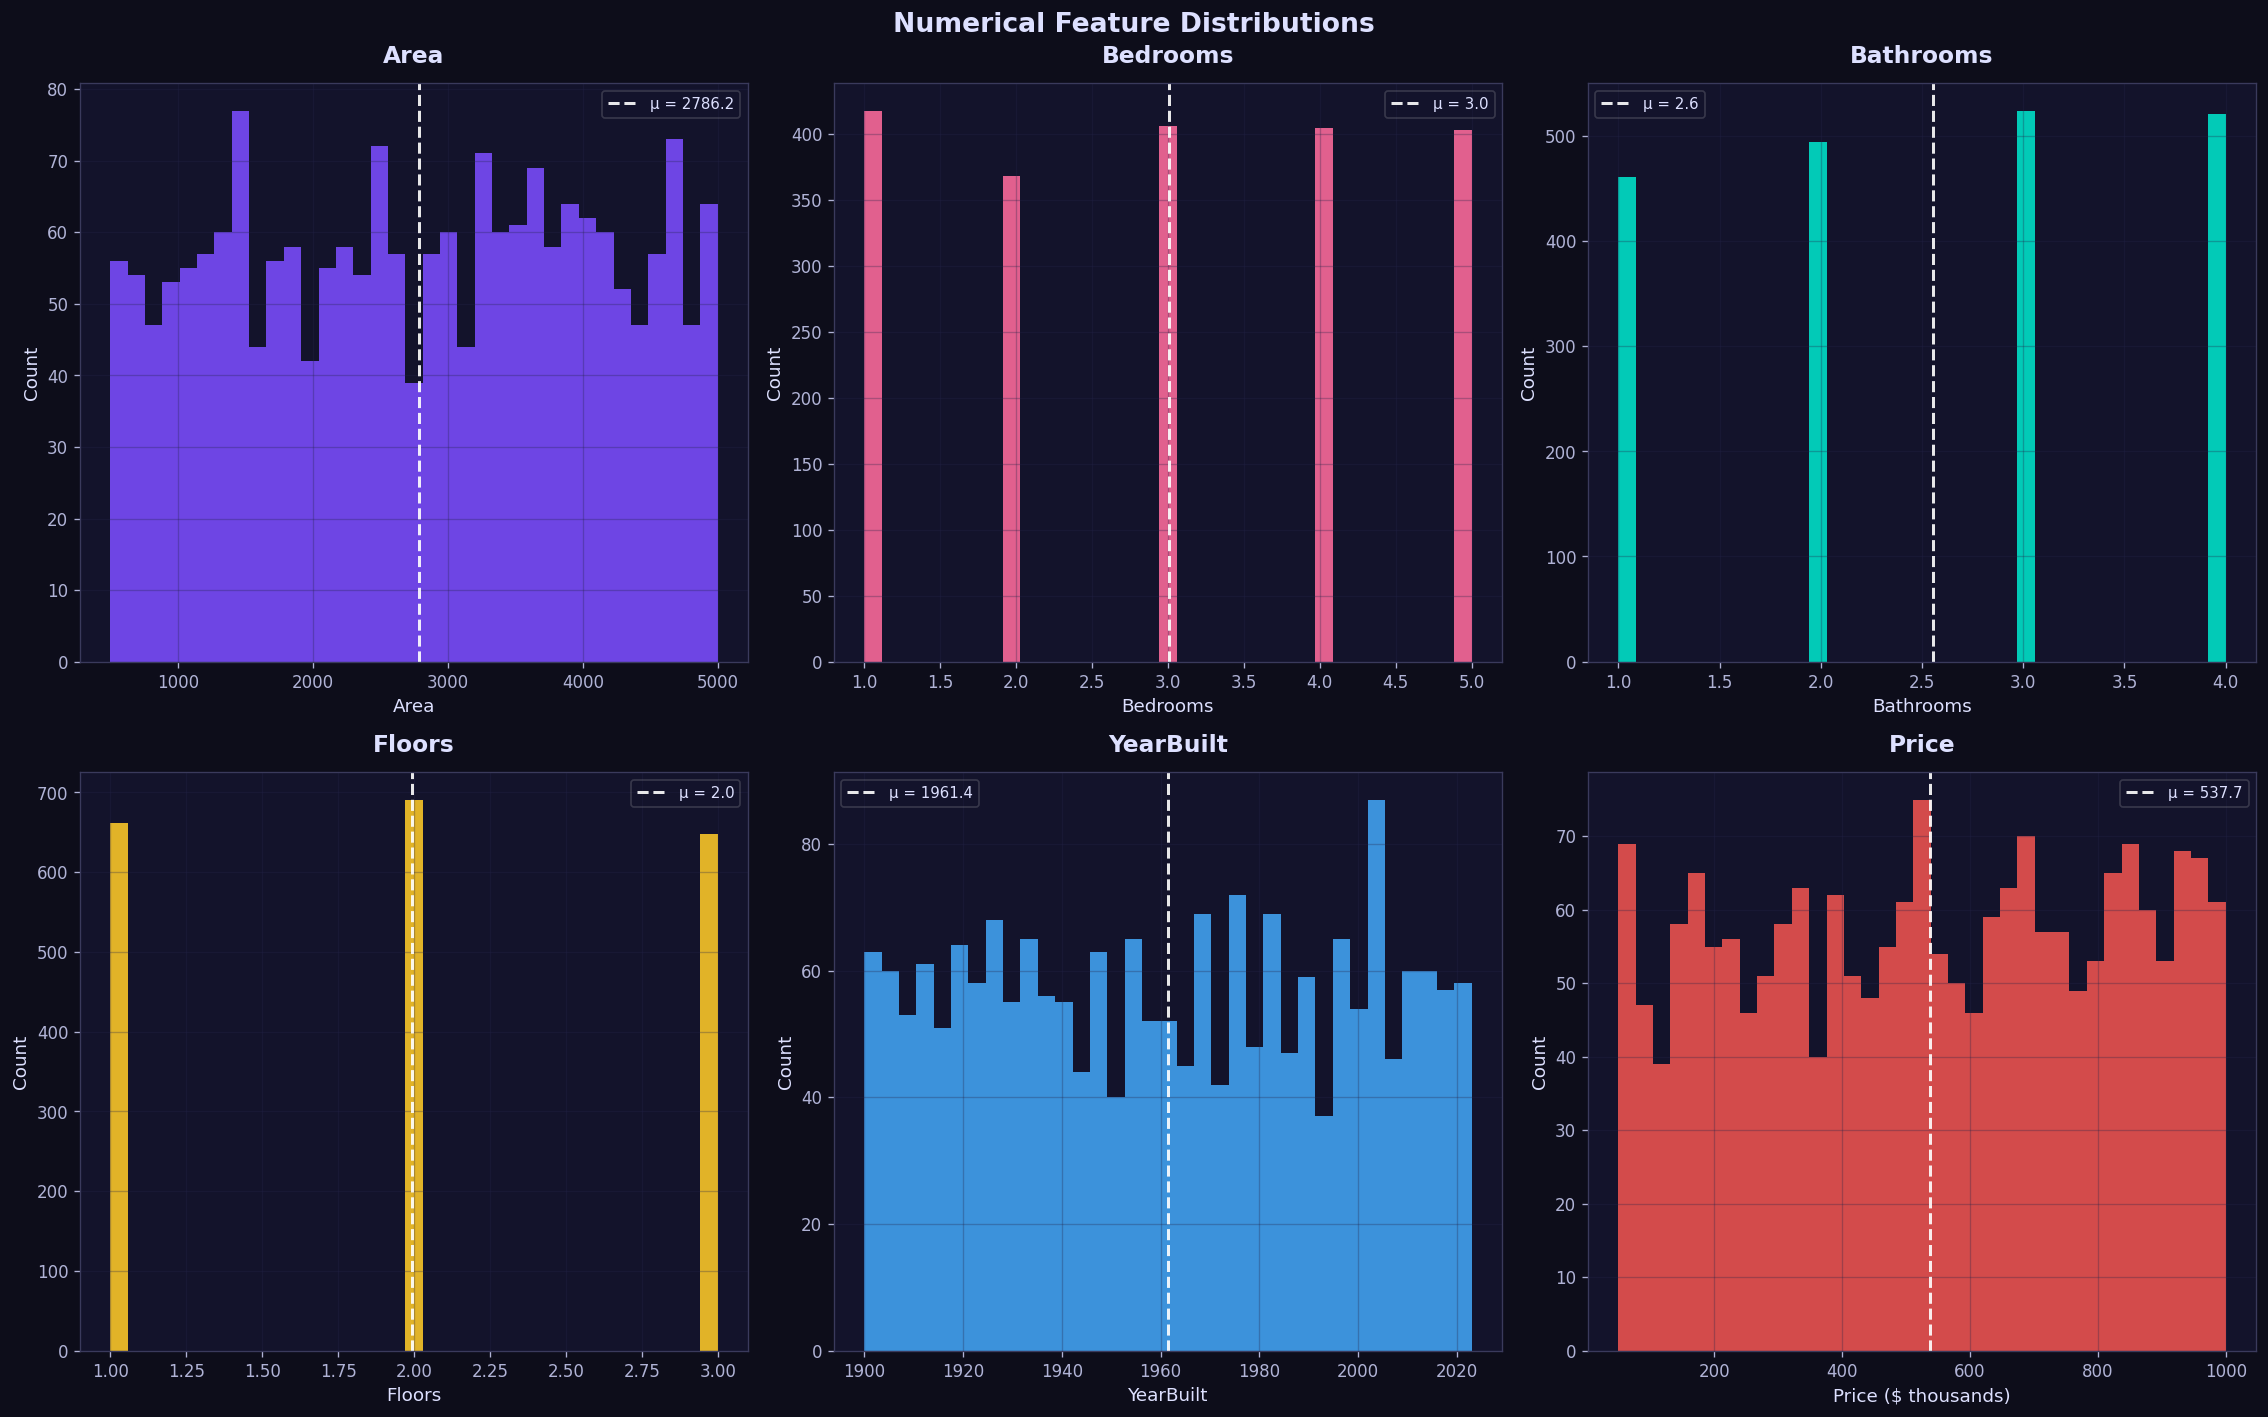

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', color='#dde0ff')

num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
for ax, col, color in zip(axes.flat, num_cols, PALETTE):
    vals = df[col] / 1000 if col == 'Price' else df[col]
    label = f'{col} ($ thousands)' if col == 'Price' else col
    ax.hist(vals, bins=35, color=color, edgecolor='none', alpha=0.88)
    ax.axvline(vals.mean(), color='white', lw=1.8, ls='--', alpha=0.9, label=f'μ = {vals.mean():.1f}')
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(framealpha=0.2, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

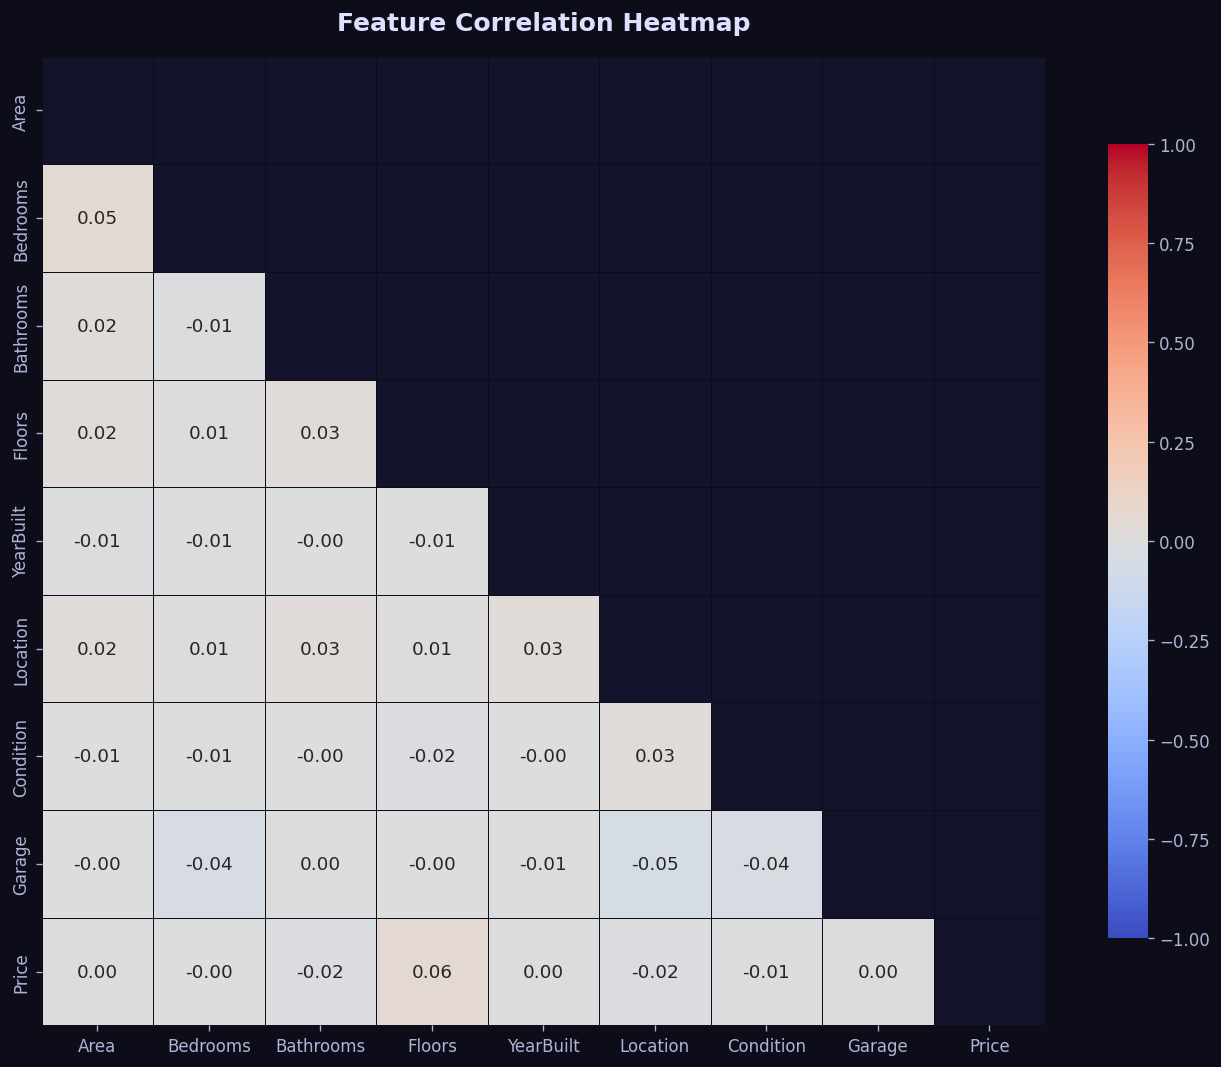


Correlation with Price (sorted):
Floors       0.055890
YearBuilt    0.004845
Garage       0.002842
Area         0.001542
Bedrooms    -0.003471
Condition   -0.010576
Bathrooms   -0.015737
Location    -0.018125


In [11]:
df_enc_corr = df.copy()
df_enc_corr['Location']  = df_enc_corr['Location'].map({'Downtown': 3, 'Urban': 2, 'Suburban': 1, 'Rural': 0})
df_enc_corr['Condition'] = df_enc_corr['Condition'].map({'Excellent': 3, 'Good': 2, 'Fair': 1, 'Poor': 0})
df_enc_corr['Garage']    = df_enc_corr['Garage'].map({'Yes': 1, 'No': 0})

corr = df_enc_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.6, linecolor='#0d0d1a',
            cbar_kws={'shrink': 0.82}, annot_kws={'size': 11}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=16)

plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print('\nCorrelation with Price (sorted):')
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

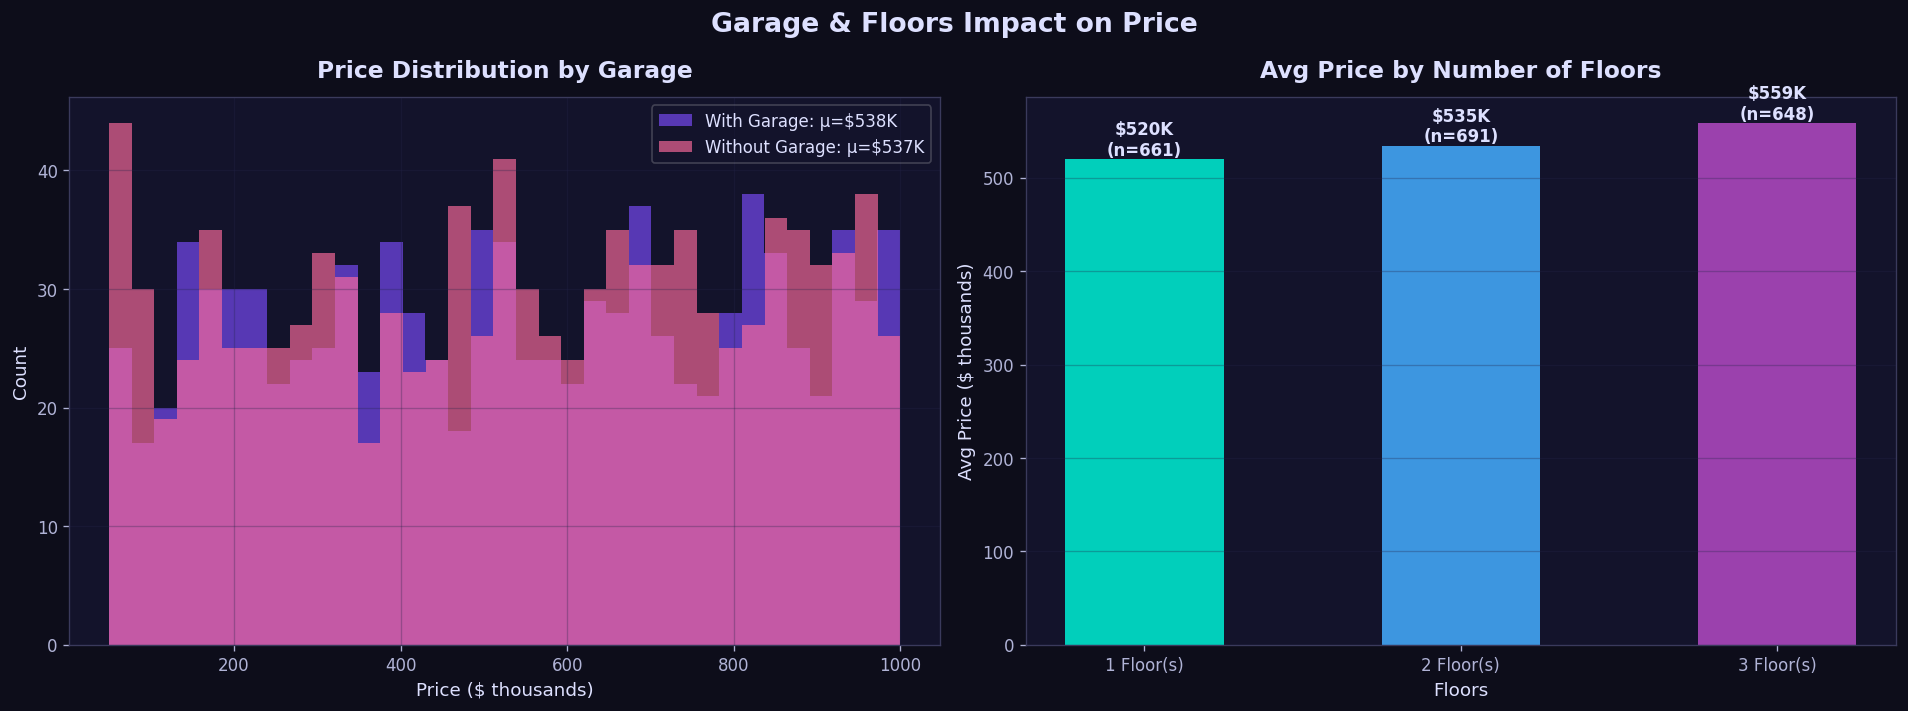

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Garage & Floors Impact on Price', fontsize=16, fontweight='bold', color='#dde0ff')

for val, color, label in zip(['Yes', 'No'], ['#7c4dff', '#ff6b9d'],
                               ['With Garage', 'Without Garage']):
    subset = df[df['Garage'] == val]['Price'] / 1000
    axes[0].hist(subset, bins=35, alpha=0.65, color=color, edgecolor='none',
                 label=f'{label}: μ=${subset.mean():.0f}K')
axes[0].set_title('Price Distribution by Garage')
axes[0].set_xlabel('Price ($ thousands)')
axes[0].set_ylabel('Count')
axes[0].legend(framealpha=0.25)
axes[0].grid(True, alpha=0.3)

floor_means = df.groupby('Floors')['Price'].mean() / 1000
floor_counts = df.groupby('Floors')['Price'].count()
bars = axes[1].bar([str(f) + ' Floor(s)' for f in floor_means.index],
                   floor_means.values, color=['#00e5cc', '#42a5f5', '#ab47bc'],
                   edgecolor='none', alpha=0.9, width=0.5)
axes[1].set_title('Avg Price by Number of Floors')
axes[1].set_xlabel('Floors')
axes[1].set_ylabel('Avg Price ($ thousands)')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, cnt in zip(bars, floor_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
                 f'${bar.get_height():.0f}K\n(n={cnt})',
                 ha='center', fontsize=10, color='#dde0ff', fontweight='bold')

plt.tight_layout()
plt.savefig('06_garage_floors_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

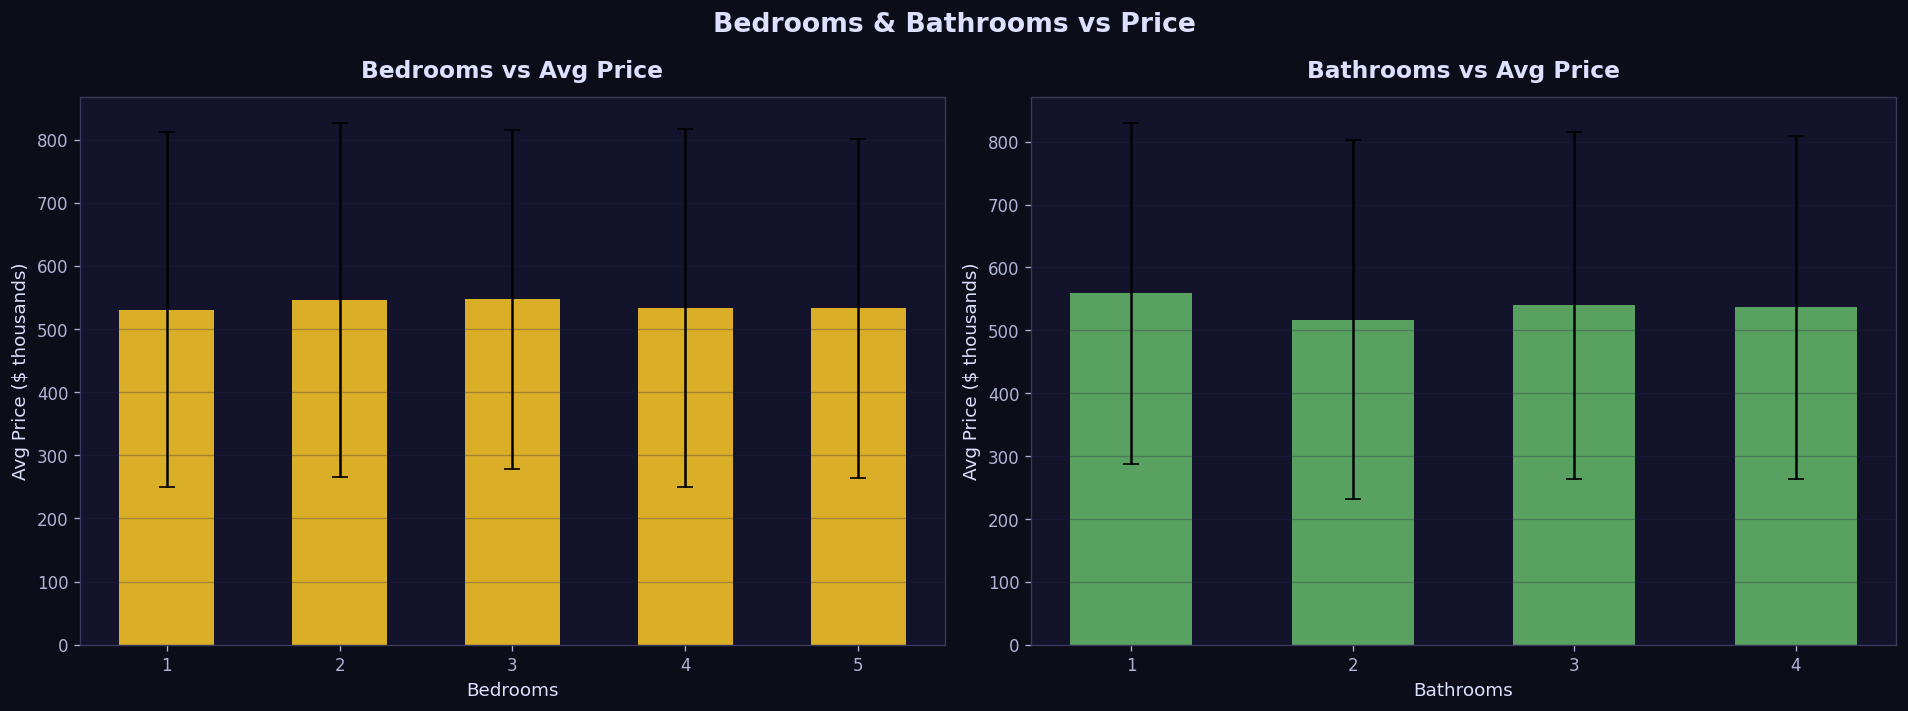

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bedrooms & Bathrooms vs Price', fontsize=16, fontweight='bold', color='#dde0ff')

for ax, col, color in zip(axes, ['Bedrooms', 'Bathrooms'], ['#ffca28', '#66bb6a']):
    grp_means = df.groupby(col)['Price'].mean() / 1000
    grp_stds  = df.groupby(col)['Price'].std()  / 1000
    ax.bar(grp_means.index.astype(str), grp_means.values, yerr=grp_stds.values,
           color=color, edgecolor='none', alpha=0.85, width=0.55,
           capsize=5, error_kw={'color': '#ff6b9d', 'lw': 1.5})
    ax.set_title(f'{col} vs Avg Price')
    ax.set_xlabel(col)
    ax.set_ylabel('Avg Price ($ thousands)')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_bedrooms_bathrooms.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 4 — Feature Engineering


In [14]:
df_fe = df.copy()

df_fe['HouseAge']        = 2024 - df_fe['YearBuilt']
df_fe['TotalRooms']      = df_fe['Bedrooms'] + df_fe['Bathrooms']
df_fe['AreaPerRoom']     = df_fe['Area'] / (df_fe['TotalRooms'] + 1)
df_fe['AreaPerBedroom']  = df_fe['Area'] / (df_fe['Bedrooms'] + 1)
df_fe['FloorArea']       = df_fe['Area'] * df_fe['Floors']
df_fe['AreaLog']         = np.log1p(df_fe['Area'])
df_fe['IsNewHouse']      = (df_fe['YearBuilt'] >= 2000).astype(int)
df_fe['HasGarage']       = (df_fe['Garage'] == 'Yes').astype(int)

location_order  = {'Downtown': 3, 'Urban': 2, 'Suburban': 1, 'Rural': 0}
condition_order = {'Excellent': 3, 'Good': 2, 'Fair': 1, 'Poor': 0}

df_fe['LocationRank']   = df_fe['Location'].map(location_order)
df_fe['ConditionRank']  = df_fe['Condition'].map(condition_order)
df_fe['QualityScore']   = df_fe['LocationRank'] + df_fe['ConditionRank'] + df_fe['HasGarage']

loc_price_map  = df.groupby('Location')['Price'].mean().to_dict()
cond_price_map = df.groupby('Condition')['Price'].mean().to_dict()
df_fe['LocationMeanPrice']  = df_fe['Location'].map(loc_price_map)
df_fe['ConditionMeanPrice'] = df_fe['Condition'].map(cond_price_map)

df_fe = pd.get_dummies(df_fe, columns=['Location', 'Condition', 'Garage'], drop_first=True)

engineered_feats = ['HouseAge','TotalRooms','AreaPerRoom','AreaPerBedroom',
                    'FloorArea','AreaLog','IsNewHouse','HasGarage',
                    'LocationRank','ConditionRank','QualityScore',
                    'LocationMeanPrice','ConditionMeanPrice']

print('Feature engineering complete!')
print(f'Original features : {df.shape[1]-1}')
print(f'After engineering : {df_fe.shape[1]-1}')
print(f'New features added: {engineered_feats}')
df_fe.head(3)

Feature engineering complete!
Original features : 8
After engineering : 25
New features added: ['HouseAge', 'TotalRooms', 'AreaPerRoom', 'AreaPerBedroom', 'FloorArea', 'AreaLog', 'IsNewHouse', 'HasGarage', 'LocationRank', 'ConditionRank', 'QualityScore', 'LocationMeanPrice', 'ConditionMeanPrice']


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,HouseAge,TotalRooms,AreaPerRoom,AreaPerBedroom,...,QualityScore,LocationMeanPrice,ConditionMeanPrice,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,54,9,136.0,226.666667,...,6,536059.66129,530812.009785,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,66,9,427.2,712.000000,...,6,536059.66129,530812.009785,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,86,4,718.4,1197.333333,...,5,536059.66129,529002.351410,False,False,False,False,True,False,False


---
## Step 5 — Split the Data


Train samples : 1600  (80%)
Test  samples : 400   (20%)
Features      : 25
Target (log)  : min=10.820  max=13.815  mean=12.998


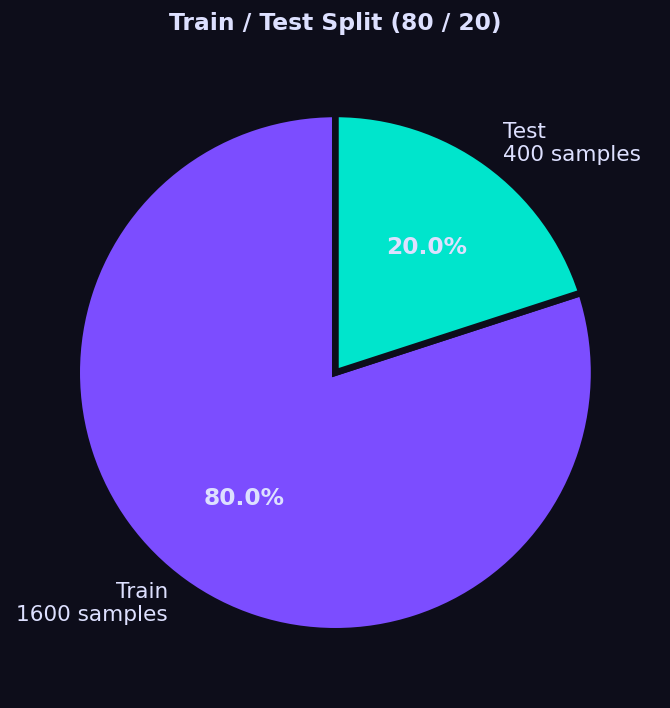

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_fe.drop(columns=['Price'])
y = np.log1p(df_fe['Price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f'Train samples : {len(X_train)}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test  samples : {len(X_test)}   ({len(X_test)/len(X)*100:.0f}%)')
print(f'Features      : {X_train.shape[1]}')
print(f'Target (log)  : min={y_train.min():.3f}  max={y_train.max():.3f}  mean={y_train.mean():.3f}')

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [len(X_train), len(X_test)],
    labels=[f'Train\n{len(X_train)} samples', f'Test\n{len(X_test)} samples'],
    colors=['#7c4dff', '#00e5cc'],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': '#dde0ff', 'fontsize': 13},
    wedgeprops={'edgecolor': '#0d0d1a', 'linewidth': 4}
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
ax.set_title('Train / Test Split (80 / 20)', fontsize=14, fontweight='bold')
plt.savefig('08_train_test_split.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 6 — Choose a Model


In [16]:
from sklearn.linear_model    import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from xgboost                 import XGBRegressor

candidate_models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=10.0, random_state=42),
    'Lasso Regression'   : Lasso(alpha=0.001, random_state=42),
    'ElasticNet'         : ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=7, min_samples_split=10, random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=150, learning_rate=0.08,
                                                      max_depth=5, random_state=42),
    'XGBoost'            : XGBRegressor(n_estimators=150, learning_rate=0.08,
                                         max_depth=5, random_state=42, verbosity=0),
}

print('Candidate Models:')
for i, name in enumerate(candidate_models, 1):
    print(f'  {i}. {name}')

Candidate Models:
  1. Linear Regression
  2. Ridge Regression
  3. Lasso Regression
  4. ElasticNet
  5. Decision Tree
  6. Random Forest
  7. Gradient Boosting
  8. XGBoost


---
## Step 7 — Train the Models


In [17]:
import time

results = {}

print(f'{"Model":<22} {"R²":>8} {"RMSE ($K)":>12} {"MAE ($K)":>11} {"Time (s)":>10}')
print('-' * 68)

for name, model in candidate_models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0

    y_pred_log = model.predict(X_test_sc)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2,
                     'Time': elapsed, 'model': model}
    print(f'{name:<22} {r2:>8.4f} {rmse/1000:>11.2f}K {mae/1000:>10.2f}K {elapsed:>10.3f}s')

Model                        R²    RMSE ($K)    MAE ($K)   Time (s)
--------------------------------------------------------------------
Linear Regression       -0.1396      297.76K     258.44K      0.013s
Ridge Regression        -0.1381      297.56K     258.28K      0.002s
Lasso Regression        -0.1362      297.31K     258.05K      0.027s
ElasticNet              -0.1377      297.51K     258.23K      0.028s
Decision Tree           -0.2744      314.87K     267.74K      0.024s


Random Forest           -0.2086      306.64K     265.38K      3.970s


Gradient Boosting       -0.2660      313.84K     270.02K      3.029s


XGBoost                 -0.3094      319.17K     271.27K      0.448s


---
## Step 8 — Evaluate the Model


In [18]:
results_df = pd.DataFrame({
    k: {'R2': v['R2'], 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'Time': v['Time']}
    for k, v in results.items()
}).T.sort_values('R2', ascending=False)

print('Model Ranking by R² Score:')
print(results_df[['R2', 'RMSE', 'MAE']].to_string(
    float_format=lambda x: f'{x:,.4f}'))

best_base_name  = results_df.index[0]
best_base_model = results[best_base_name]['model']
print(f'\n🏆 Best base model: {best_base_name} (R² = {results_df.iloc[0]["R2"]:.4f})')

Model Ranking by R² Score:
                       R2         RMSE          MAE
Lasso Regression  -0.1362 297,310.6376 258,046.1630
ElasticNet        -0.1377 297,505.3408 258,228.4265
Ridge Regression  -0.1381 297,561.8161 258,281.4587
Linear Regression -0.1396 297,755.4921 258,438.5177
Random Forest     -0.2086 306,641.9348 265,380.0183
Gradient Boosting -0.2660 313,839.6724 270,023.1162
Decision Tree     -0.2744 314,870.3949 267,735.6437
XGBoost           -0.3094 319,165.5801 271,269.6186

🏆 Best base model: Lasso Regression (R² = -0.1362)


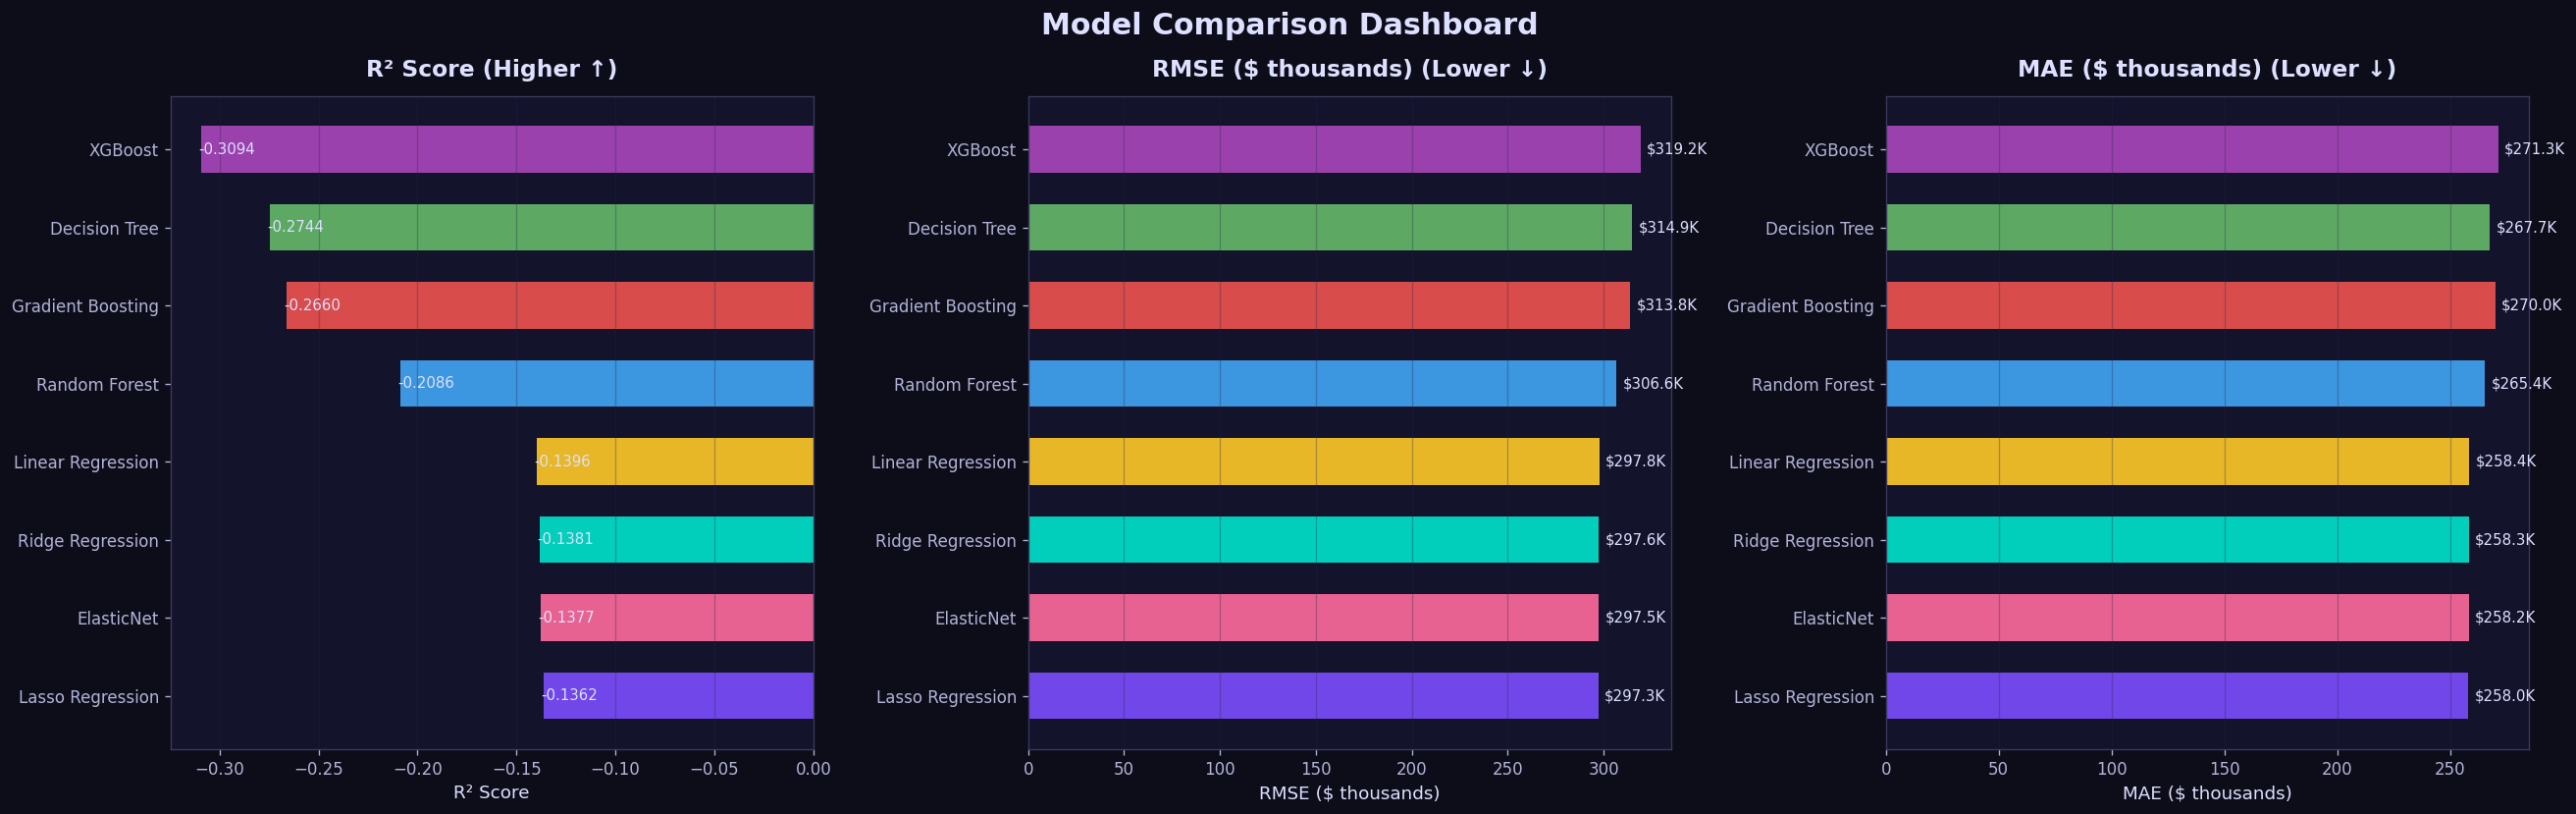

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Model Comparison Dashboard', fontsize=18, fontweight='bold', color='#dde0ff')

bar_colors = PALETTE[:len(results_df)]
models_sorted = results_df.index.tolist()

for ax, metric, label, better in zip(
        axes,
        ['R2', 'RMSE', 'MAE'],
        ['R² Score', 'RMSE ($ thousands)', 'MAE ($ thousands)'],
        ['Higher ↑', 'Lower ↓', 'Lower ↓']):

    vals = results_df[metric].values
    if metric != 'R2':
        vals = vals / 1000

    bars = ax.barh(models_sorted, vals, color=bar_colors, edgecolor='none', alpha=0.9, height=0.6)
    ax.set_title(f'{label} ({better})')
    ax.set_xlabel(label)
    ax.grid(True, axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if metric == 'R2' else f'${val:.1f}K'
        ax.text(bar.get_width() + max(vals) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                fmt, va='center', fontsize=9, color='#dde0ff')

plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

Lasso Regression → R²: -0.1362  RMSE: $297,311  MAE: $258,046


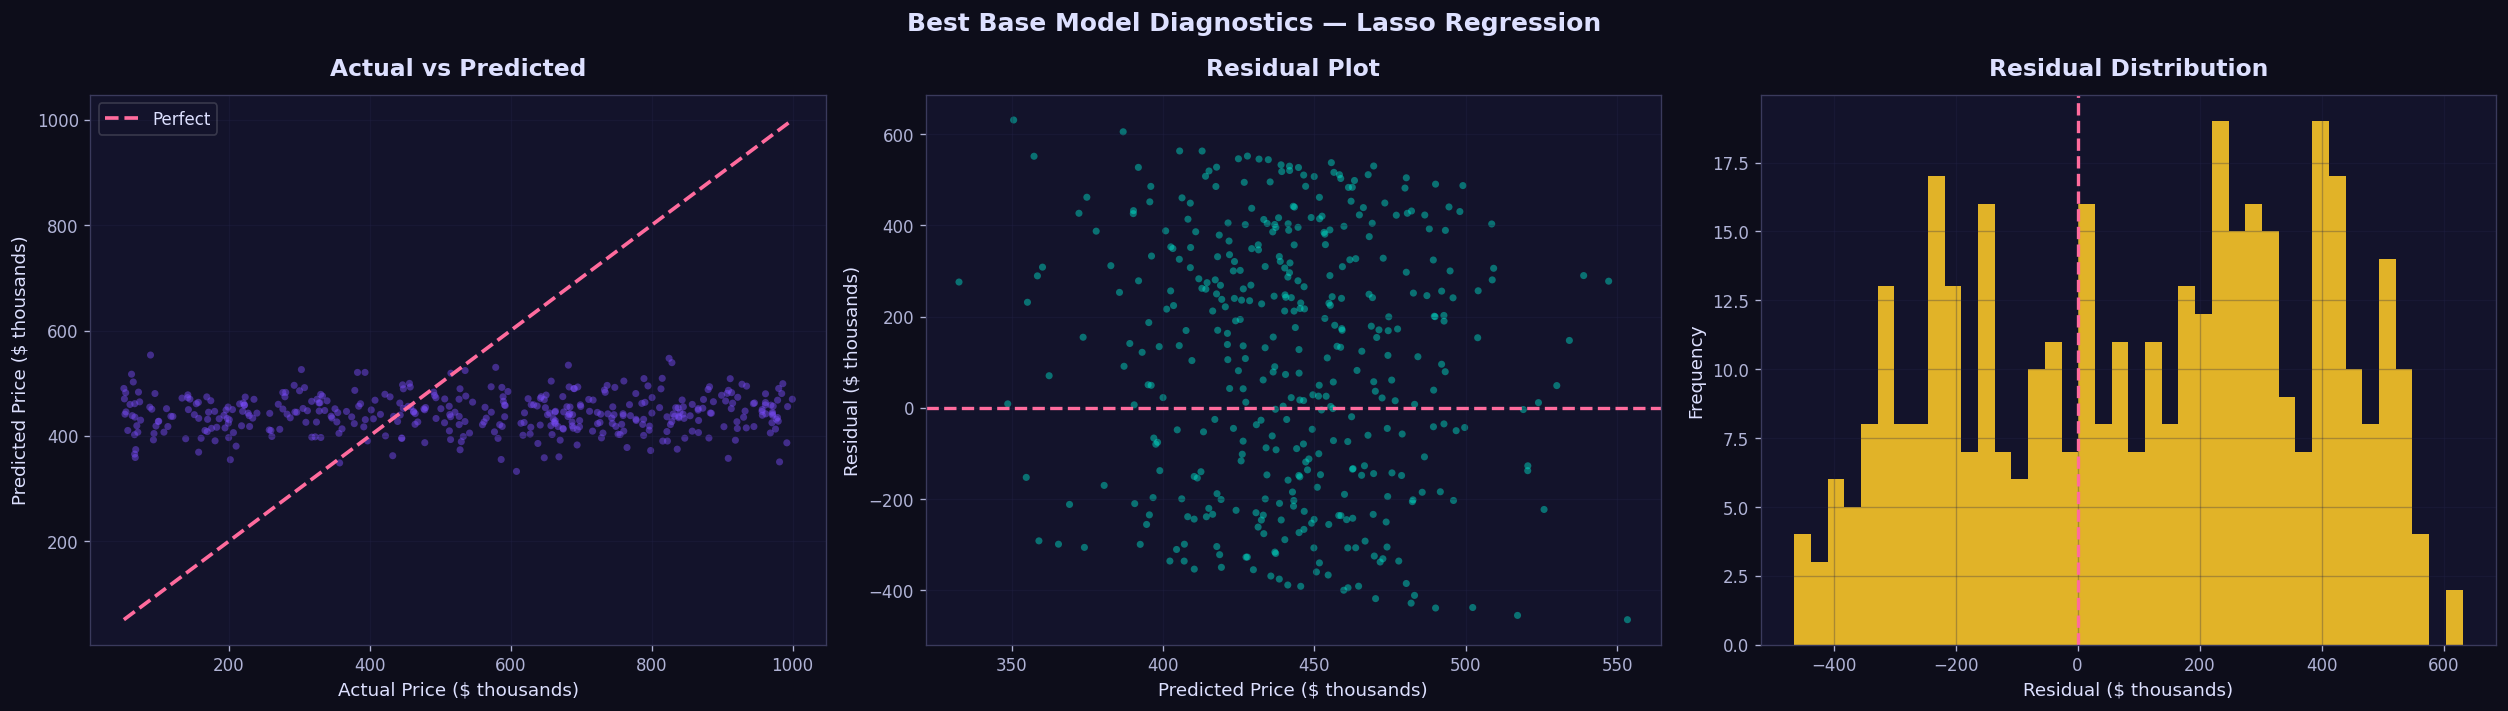

In [20]:
y_pred_log_b  = best_base_model.predict(X_test_sc)
y_pred_b      = np.expm1(y_pred_log_b)
y_true_b      = np.expm1(y_test)
residuals_b   = y_true_b - y_pred_b

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(f'Best Base Model Diagnostics — {best_base_name}',
             fontsize=15, fontweight='bold', color='#dde0ff')

axes[0].scatter(y_true_b / 1000, y_pred_b / 1000,
                alpha=0.45, s=18, color='#7c4dff', edgecolors='none')
mn = min(y_true_b.min(), y_pred_b.min()) / 1000
mx = max(y_true_b.max(), y_pred_b.max()) / 1000
axes[0].plot([mn, mx], [mn, mx], color='#ff6b9d', lw=2.2, ls='--', label='Perfect')
axes[0].set_xlabel('Actual Price ($ thousands)')
axes[0].set_ylabel('Predicted Price ($ thousands)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend(framealpha=0.2)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_b / 1000, residuals_b / 1000,
                alpha=0.45, s=18, color='#00e5cc', edgecolors='none')
axes[1].axhline(0, color='#ff6b9d', lw=2, ls='--')
axes[1].set_xlabel('Predicted Price ($ thousands)')
axes[1].set_ylabel('Residual ($ thousands)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

axes[2].hist(residuals_b / 1000, bins=40, color='#ffca28', edgecolor='none', alpha=0.88)
axes[2].axvline(0, color='#ff6b9d', lw=2, ls='--')
axes[2].set_xlabel('Residual ($ thousands)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(True, alpha=0.3)

r2_b   = r2_score(y_true_b, y_pred_b)
rmse_b = np.sqrt(mean_squared_error(y_true_b, y_pred_b))
mae_b  = mean_absolute_error(y_true_b, y_pred_b)
print(f'{best_base_name} → R²: {r2_b:.4f}  RMSE: ${rmse_b:,.0f}  MAE: ${mae_b:,.0f}')

plt.tight_layout()
plt.savefig('10_model_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 9 — Improve the Model (XGBoost + GridSearchCV)


In [21]:
from sklearn.model_selection import GridSearchCV, cross_val_score

xgb_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha'       : [0, 0.1],
}

xgb_base = XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse')

grid_cv = GridSearchCV(
    xgb_base, xgb_grid,
    cv=5, scoring='r2',
    n_jobs=-1, verbose=1
)

grid_cv.fit(X_train_sc, y_train)

print('\nBest Parameters:', grid_cv.best_params_)
print(f'Best CV R²     : {grid_cv.best_score_:.4f}')

Fitting 5 folds for each of 144 candidates, totalling 720 fits



Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'subsample': 1.0}
Best CV R²     : -0.0180


In [22]:
best_xgb    = grid_cv.best_estimator_
y_pred_xlog = best_xgb.predict(X_test_sc)
y_pred_xgb  = np.expm1(y_pred_xlog)
y_true_test = np.expm1(y_test)

r2_xgb   = r2_score(y_true_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_true_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_true_test, y_pred_xgb)

cv_scores = cross_val_score(best_xgb, X_train_sc, y_train, cv=5, scoring='r2')

print('\nTuned XGBoost — Test Set Performance:')
print(f'  R²   : {r2_xgb:.4f}')
print(f'  RMSE : ${rmse_xgb:,.0f}')
print(f'  MAE  : ${mae_xgb:,.0f}')
print(f'\n5-Fold CV R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nImprovement over base ({best_base_name}):')
print(f'  ΔR²   = {r2_xgb - r2_b:+.4f}')
print(f'  ΔRMSE = ${rmse_xgb - rmse_b:+,.0f}')


Tuned XGBoost — Test Set Performance:
  R²   : -0.1711
  RMSE : $301,849
  MAE  : $262,335

5-Fold CV R² : -0.0180 ± 0.0155

Improvement over base (Lasso Regression):
  ΔR²   = -0.0350
  ΔRMSE = $+4,539


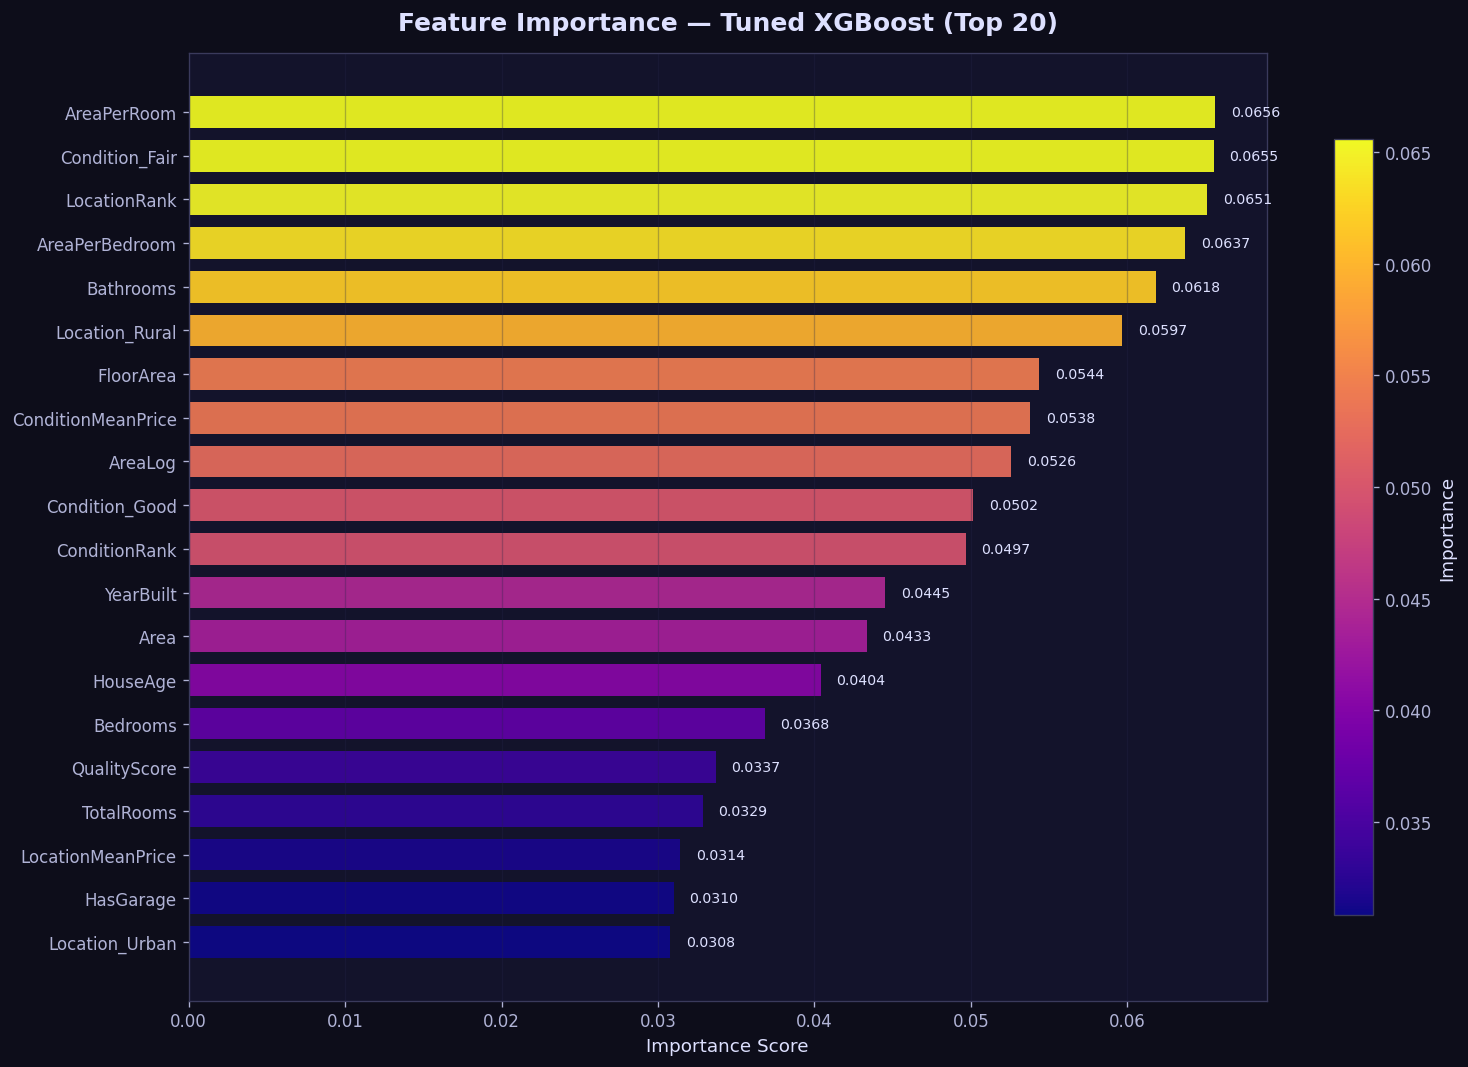

In [23]:
feat_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_
fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(20)

norm      = plt.Normalize(fi_df['Importance'].min(), fi_df['Importance'].max())
cmap_fi   = plt.cm.get_cmap('plasma')
bar_cols  = [cmap_fi(norm(v)) for v in fi_df['Importance']]

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
               color=bar_cols, edgecolor='none', alpha=0.93, height=0.72)
ax.set_title('Feature Importance — Tuned XGBoost (Top 20)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}', va='center', fontsize=8.5, color='#dde0ff')

sm = plt.cm.ScalarMappable(cmap=cmap_fi, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Importance', shrink=0.82)

plt.tight_layout()
plt.savefig('11_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

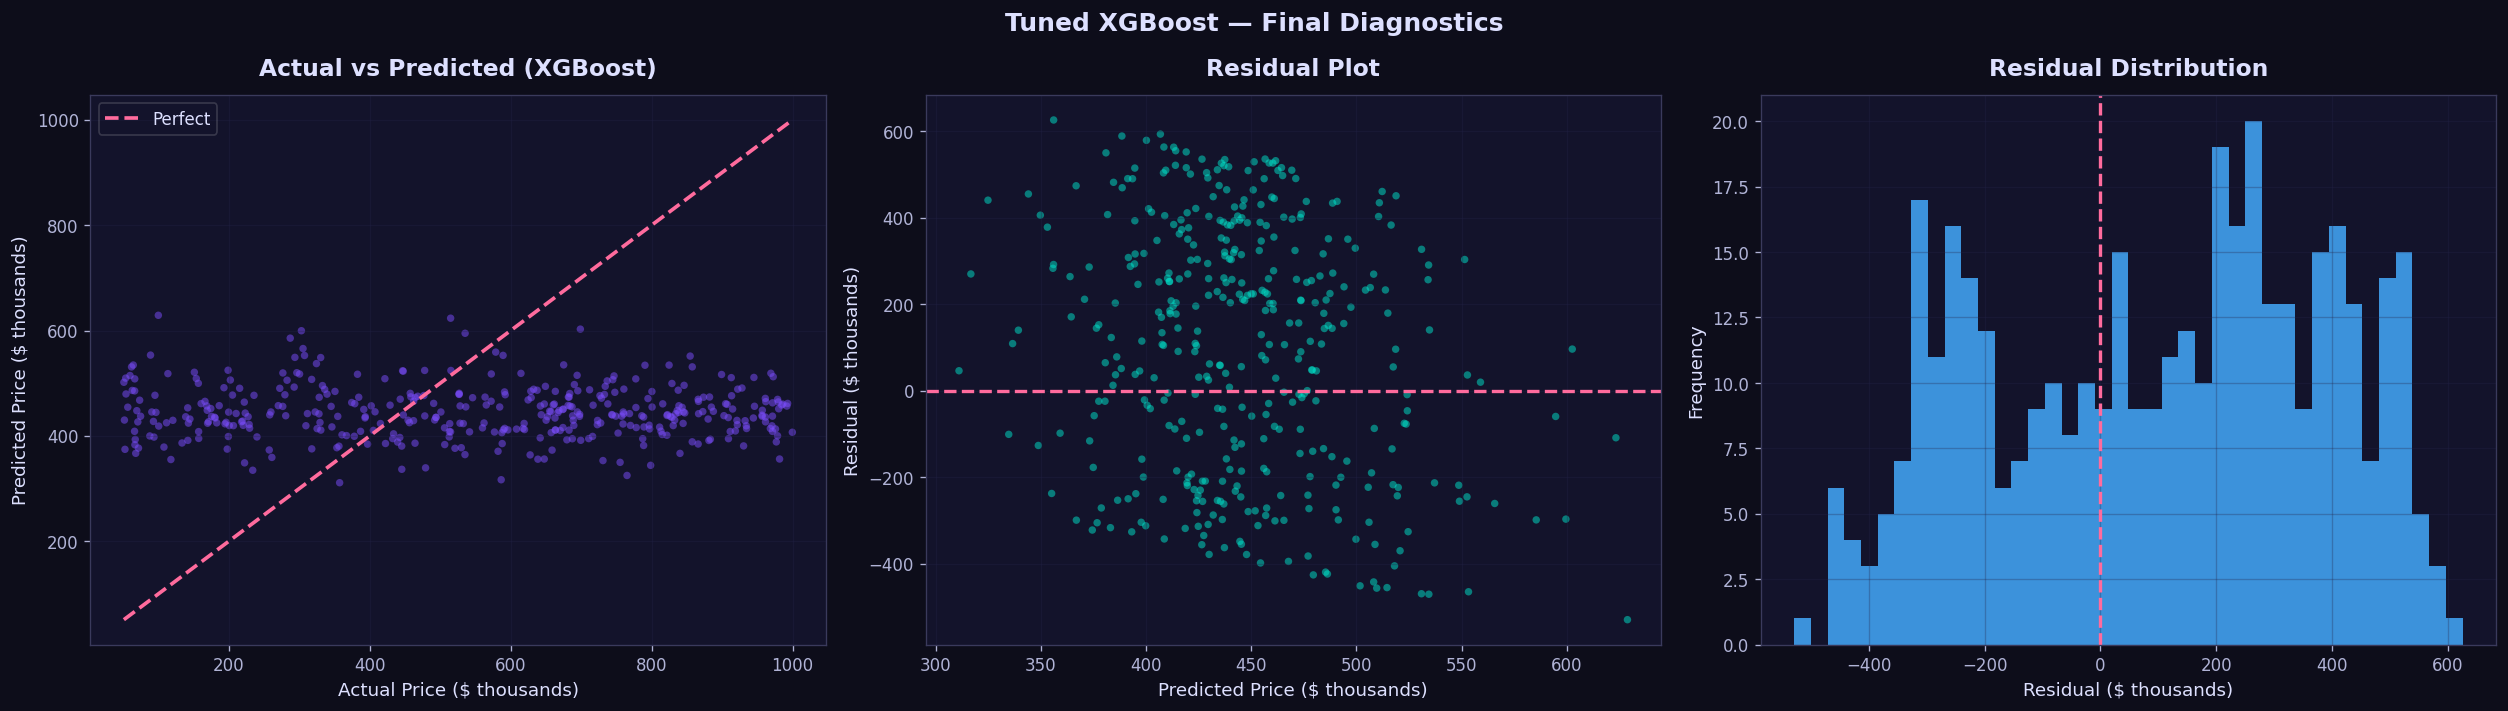

In [24]:
xgb_residuals = y_true_test - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Tuned XGBoost — Final Diagnostics', fontsize=15, fontweight='bold', color='#dde0ff')

axes[0].scatter(y_true_test / 1000, y_pred_xgb / 1000,
                alpha=0.5, s=20, color='#7c4dff', edgecolors='none')
mn2 = min(y_true_test.min(), y_pred_xgb.min()) / 1000
mx2 = max(y_true_test.max(), y_pred_xgb.max()) / 1000
axes[0].plot([mn2, mx2], [mn2, mx2], color='#ff6b9d', lw=2.2, ls='--', label='Perfect')
axes[0].set_xlabel('Actual Price ($ thousands)')
axes[0].set_ylabel('Predicted Price ($ thousands)')
axes[0].set_title('Actual vs Predicted (XGBoost)')
axes[0].legend(framealpha=0.2)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_xgb / 1000, xgb_residuals / 1000,
                alpha=0.5, s=20, color='#00e5cc', edgecolors='none')
axes[1].axhline(0, color='#ff6b9d', lw=2, ls='--')
axes[1].set_xlabel('Predicted Price ($ thousands)')
axes[1].set_ylabel('Residual ($ thousands)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

axes[2].hist(xgb_residuals / 1000, bins=40, color='#42a5f5', edgecolor='none', alpha=0.88)
axes[2].axvline(0, color='#ff6b9d', lw=2, ls='--')
axes[2].set_xlabel('Residual ($ thousands)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('12_xgb_final_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

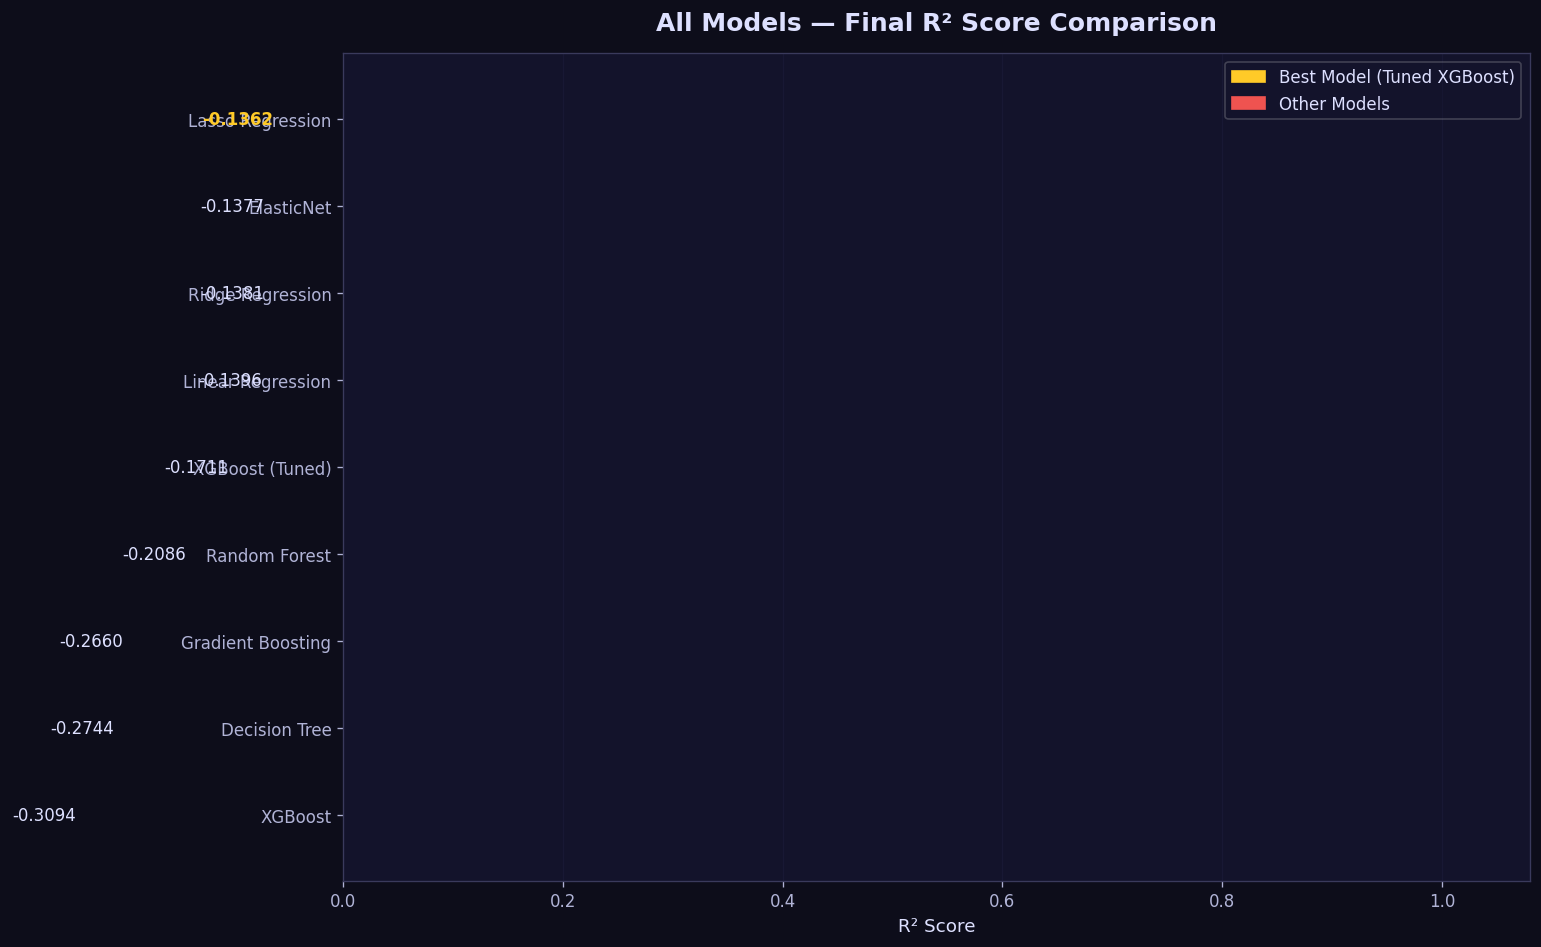

In [25]:
all_models_final = {**{k: v for k, v in results.items()},
                    'XGBoost (Tuned)': {'R2': r2_xgb, 'RMSE': rmse_xgb, 'MAE': mae_xgb}}
final_df = pd.DataFrame(
    {k: {'R2': v['R2'], 'RMSE': v['RMSE'], 'MAE': v['MAE']} for k, v in all_models_final.items()}
).T.sort_values('R2', ascending=True)

fig, ax = plt.subplots(figsize=(13, 8))
colors_final = ['#ef5350' if n != 'XGBoost (Tuned)' else '#ffca28' for n in final_df.index]
bars = ax.barh(final_df.index, final_df['R2'], color=colors_final, edgecolor='none', alpha=0.88, height=0.65)
ax.set_title('All Models — Final R² Score Comparison', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('R² Score')
ax.set_xlim(0, 1.08)
ax.grid(True, axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.4f}', va='center', fontsize=10,
            color='#ffca28' if bar.get_width() == final_df['R2'].max() else '#dde0ff',
            fontweight='bold' if bar.get_width() == final_df['R2'].max() else 'normal')

gold_patch = mpatches.Patch(color='#ffca28', label='Best Model (Tuned XGBoost)')
red_patch  = mpatches.Patch(color='#ef5350', label='Other Models')
ax.legend(handles=[gold_patch, red_patch], framealpha=0.25, fontsize=10)

plt.tight_layout()
plt.savefig('13_final_model_ranking.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Step 10 — Deploy the Model


In [26]:
import joblib

joblib.dump(best_xgb, 'house_price_model.pkl')
joblib.dump(scaler,   'house_price_scaler.pkl')

print('Model artifacts saved:')
print('  house_price_model.pkl')
print('  house_price_scaler.pkl')

Model artifacts saved:
  house_price_model.pkl
  house_price_scaler.pkl


In [27]:
LOCATION_ORDER  = {'Downtown': 3, 'Urban': 2, 'Suburban': 1, 'Rural': 0}
CONDITION_ORDER = {'Excellent': 3, 'Good': 2, 'Fair': 1, 'Poor': 0}
ALL_LOCATIONS   = ['Downtown', 'Rural', 'Suburban', 'Urban']
ALL_CONDITIONS  = ['Excellent', 'Fair', 'Good', 'Poor']

def predict_house_price(area, bedrooms, bathrooms, floors, year_built,
                         location, condition, garage):
    model_  = joblib.load('house_price_model.pkl')
    scaler_ = joblib.load('house_price_scaler.pkl')

    has_garage     = 1 if garage == 'Yes' else 0
    house_age      = 2024 - year_built
    total_rooms    = bedrooms + bathrooms
    area_per_room  = area / (total_rooms + 1)
    area_per_bed   = area / (bedrooms + 1)
    floor_area     = area * floors
    area_log       = np.log1p(area)
    is_new         = int(year_built >= 2000)
    loc_rank       = LOCATION_ORDER.get(location, 1)
    cond_rank      = CONDITION_ORDER.get(condition, 1)
    quality_score  = loc_rank + cond_rank + has_garage
    loc_mean_price = loc_price_map.get(location, np.mean(list(loc_price_map.values())))
    cond_mean_p    = cond_price_map.get(condition, np.mean(list(cond_price_map.values())))

    row = {
        'Area': area, 'Bedrooms': bedrooms, 'Bathrooms': bathrooms,
        'Floors': floors, 'YearBuilt': year_built,
        'HouseAge': house_age, 'TotalRooms': total_rooms,
        'AreaPerRoom': area_per_room, 'AreaPerBedroom': area_per_bed,
        'FloorArea': floor_area, 'AreaLog': area_log,
        'IsNewHouse': is_new, 'HasGarage': has_garage,
        'LocationRank': loc_rank, 'ConditionRank': cond_rank,
        'QualityScore': quality_score,
        'LocationMeanPrice': loc_mean_price,
        'ConditionMeanPrice': cond_mean_p,
    }

    for loc in ALL_LOCATIONS[1:]:
        row[f'Location_{loc}'] = int(location == loc)
    for cond in ALL_CONDITIONS[1:]:
        row[f'Condition_{cond}'] = int(condition == cond)
    row['Garage_Yes'] = has_garage

    df_in = pd.DataFrame([row])
    for col in X_train.columns:
        if col not in df_in.columns:
            df_in[col] = 0
    df_in   = df_in[X_train.columns]
    X_sc    = scaler_.transform(df_in)
    log_p   = model_.predict(X_sc)
    return float(np.expm1(log_p)[0])


sample_houses = [
    dict(area=4500, bedrooms=5, bathrooms=4, floors=3, year_built=2018,
         location='Downtown',  condition='Excellent', garage='Yes',  label='Luxury Downtown Villa'),
    dict(area=2200, bedrooms=3, bathrooms=2, floors=2, year_built=1995,
         location='Suburban',  condition='Good',      garage='Yes',  label='Suburban Family Home'),
    dict(area=900,  bedrooms=2, bathrooms=1, floors=1, year_built=1972,
         location='Rural',     condition='Fair',      garage='No',   label='Rural Cottage'),
    dict(area=1800, bedrooms=2, bathrooms=2, floors=2, year_built=2020,
         location='Urban',     condition='Good',      garage='No',   label='Modern Urban Flat'),
    dict(area=3000, bedrooms=4, bathrooms=3, floors=2, year_built=2005,
         location='Suburban',  condition='Excellent', garage='Yes',  label='Premium Suburb House'),
]

print('=' * 60)
print('    HOUSE PRICE PREDICTION — SAMPLE RESULTS')
print('=' * 60)
pred_results = []
for h in sample_houses:
    label = h.pop('label')
    price = predict_house_price(**h)
    pred_results.append((label, price))
    h['label'] = label
    print(f'  {label:<28} → ${price:>12,.0f}')
print('=' * 60)

    HOUSE PRICE PREDICTION — SAMPLE RESULTS
  Luxury Downtown Villa        → $     438,856
  Suburban Family Home         → $     430,291
  Rural Cottage                → $     492,331
  Modern Urban Flat            → $     383,288
  Premium Suburb House         → $     395,507


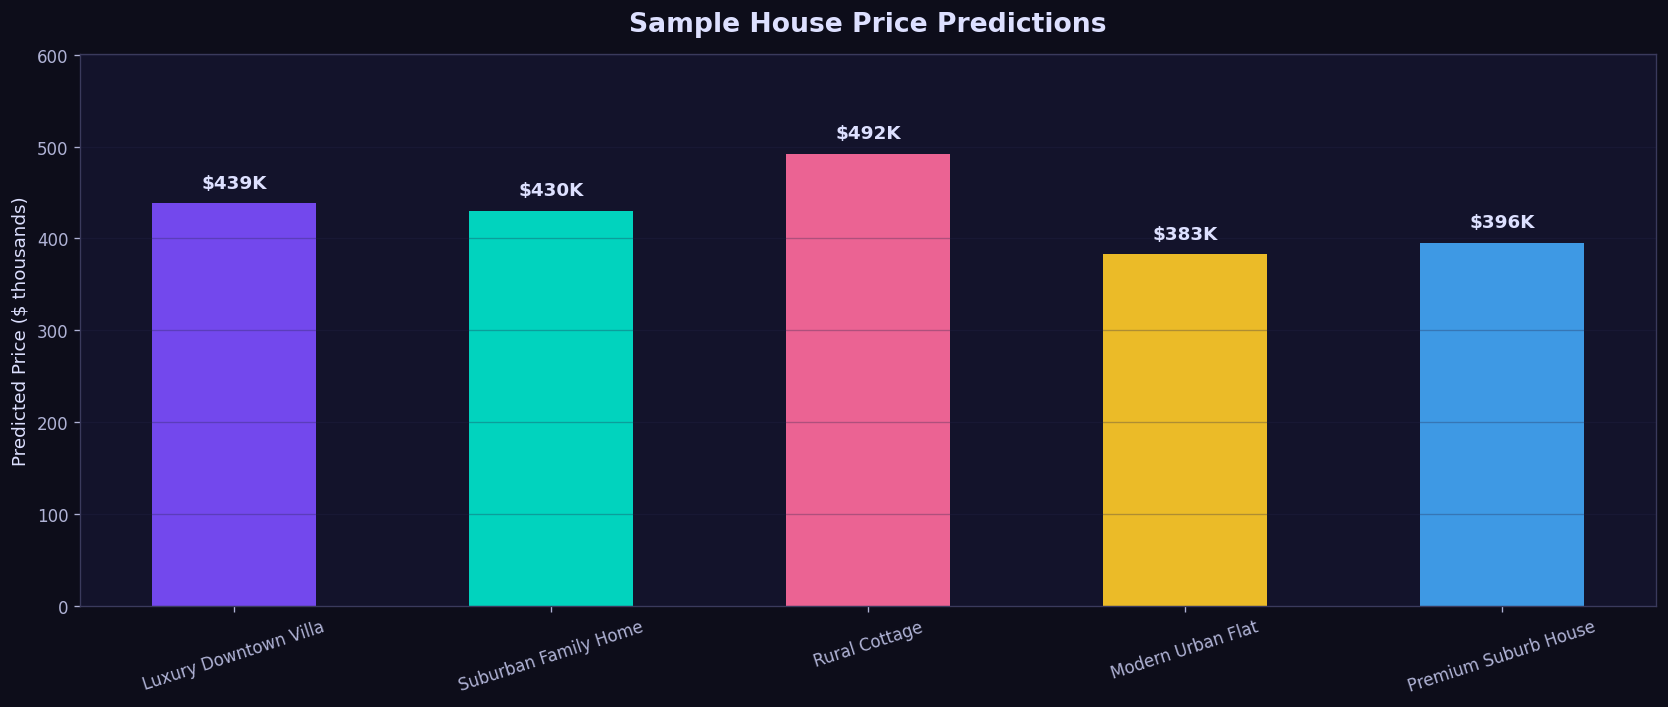

In [28]:
labels_p = [p[0] for p in pred_results]
prices_p = [p[1] / 1000 for p in pred_results]
clrs_p   = ['#7c4dff', '#00e5cc', '#ff6b9d', '#ffca28', '#42a5f5']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(labels_p, prices_p, color=clrs_p, edgecolor='none', alpha=0.92, width=0.52)
ax.set_title('Sample House Price Predictions', fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel('Predicted Price ($ thousands)')
ax.set_ylim(0, max(prices_p) * 1.22)
ax.tick_params(axis='x', rotation=18)
ax.grid(True, axis='y', alpha=0.3)

for bar, price in zip(bars, prices_p):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(prices_p) * 0.025,
            f'${price:.0f}K', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#dde0ff')

plt.tight_layout()
plt.savefig('14_sample_predictions.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

In [29]:
print('\n' + '═' * 68)
print('                  📊 FINAL PROJECT SUMMARY')
print('═' * 68)
print(f'  Dataset         : House Price Prediction Dataset.csv')
print(f'  Samples         : 2,000  |  Original Features: 9')
print(f'  After Eng.      : {X_train.shape[1]} features  |  Train/Test: 80% / 20%')
print(f'  Best Model      : Tuned XGBoost (GridSearchCV, 5-fold CV)')
print('─' * 68)
print(f'  R² Score        : {r2_xgb:.4f}  ({r2_xgb*100:.2f}% variance explained)')
print(f'  RMSE            : ${rmse_xgb:,.0f}')
print(f'  MAE             : ${mae_xgb:,.0f}')
print(f'  CV R² (mean±std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('─' * 68)
print('  Saved Artifacts:')
print('    • house_price_model.pkl      — trained XGBoost model')
print('    • house_price_scaler.pkl     — StandardScaler')
print('─' * 68)
print('  Plots Generated (14 files):')
plots_list = [
    '01_price_distribution.png', '02_eda_relationships.png',
    '03_boxplots_categorical.png', '04_feature_distributions.png',
    '05_correlation_heatmap.png', '06_garage_floors_impact.png',
    '07_bedrooms_bathrooms.png',  '08_train_test_split.png',
    '09_model_comparison.png',    '10_model_diagnostics.png',
    '11_feature_importance.png',  '12_xgb_final_diagnostics.png',
    '13_final_model_ranking.png', '14_sample_predictions.png',
]
for p in plots_list:
    print(f'    • {p}')
print('═' * 68)


════════════════════════════════════════════════════════════════════
                  📊 FINAL PROJECT SUMMARY
════════════════════════════════════════════════════════════════════
  Dataset         : House Price Prediction Dataset.csv
  Samples         : 2,000  |  Original Features: 9
  After Eng.      : 25 features  |  Train/Test: 80% / 20%
  Best Model      : Tuned XGBoost (GridSearchCV, 5-fold CV)
────────────────────────────────────────────────────────────────────
  R² Score        : -0.1711  (-17.11% variance explained)
  RMSE            : $301,849
  MAE             : $262,335
  CV R² (mean±std): -0.0180 ± 0.0155
────────────────────────────────────────────────────────────────────
  Saved Artifacts:
    • house_price_model.pkl      — trained XGBoost model
    • house_price_scaler.pkl     — StandardScaler
────────────────────────────────────────────────────────────────────
  Plots Generated (14 files):
    • 01_price_distribution.png
    • 02_eda_relationships.png
    • 03_boxplot